# NB07 — Optimización de hiperparámetros y modelos avanzados

**Proyecto:** Análisis de patrones espacio-temporales de accidentes de tránsito en El Salvador
**Etapa:** 2 — Modelos avanzados
**Notebook previo:** NB05 — Corrección de exposición y tendencia temporal

---

## 1. Introducción

NB05 corrigió la matriz de entrada y reentrenó sobre ella los tres modelos de
frecuencia de la Etapa 1, sin ampliar el conjunto de algoritmos. Este notebook
retoma esa matriz corregida y amplía el arsenal en tres direcciones: búsqueda
sistemática de hiperparámetros, modelos de gradiente por refuerzo, y modelos de
conteo con componente explícito de exceso de ceros.

La ampliación no es un fin en sí mismo. Responde a un problema concreto que
NB05 dejó abierto y que se formula en la subsección siguiente.

### 1.1 El problema heredado: calibración contra ordenamiento

La corrección de la exposición produjo un efecto doble sobre el Random Forest,
documentado en la Sección 11.6 de NB05.

| Especificación | Calibración (pred/obs) | Spearman global | Spearman tercil alto |
|---|---|---|---|
| Random Forest Etapa 1 | 0.8196 | 0.9903 | 0.9732 |
| Random Forest NB05 (v2) | 1.0057 | 0.9373 | 0.9456 |

La versión corregida estima correctamente el nivel de siniestralidad —predice el
100.6% de lo observado, frente al 82% de la Etapa 1— pero ordena peor los
distritos. La correlación de rangos frente a lo observado cae de 0.9903 a
0.9373, y dentro del tercio de distritos con mayor siniestralidad, de 0.9732 a
0.9456.

**Origen del efecto.** En el Random Forest la exposición no opera como offset
sino como variable de partición. La corrección desplaza `log_exposicion` de
forma uniforme en el tiempo, pero ese desplazamiento uniforme no produce un
efecto uniforme sobre las predicciones: cada celda puede cruzar un umbral
distinto del árbol y aterrizar en una hoja con un valor que no guarda relación
proporcional con el que tenía antes. La corrección de escala se convierte, al
atravesar la estructura de particiones, en una perturbación del orden.

**Por qué importa el orden.** El producto del sistema es una priorización
territorial: qué distritos concentran el riesgo y merecen recursos preventivos.
Si el modelo acierta la magnitud nacional pero confunde las posiciones
relativas, la magnitud correcta no compensa la recomendación equivocada. Las
dos propiedades son necesarias, no intercambiables.

### 1.2 Objetivos del notebook

1. **Establecer un protocolo de evaluación** que permita seleccionar modelos sin
   utilizar el conjunto de prueba, y que mida de forma explícita las dos
   dimensiones en conflicto: calibración y capacidad ordinal.

2. **Optimizar XGBoost mediante Optuna** sobre ese protocolo, contrastando dos
   tratamientos alternativos de la exposición —como variable predictora y como
   offset— para determinar si el mecanismo aditivo del gradiente por refuerzo se
   comporta distinto ante la corrección de NB05.

3. **Evaluar la regularización del Random Forest** como vía alternativa: si la
   pérdida ordinal proviene de la sensibilidad de las particiones, limitar la
   profundidad y exigir hojas más pobladas debería atenuarla.

4. **Ajustar modelos inflados en ceros** (ZIP y ZINB), que modelan de forma
   separada el proceso que genera las celdas nulas y el que genera los conteos
   positivos, frente al 89.7% de ceros de la matriz.

5. **Medir el aporte de `poblacion_baja`**, señalada en NB05 como candidata a
   eliminación por su importancia de 0.0001 en el Random Forest v2.

6. **Interpretar el modelo seleccionado** mediante SHAP y contrastar sus
   atribuciones con los efectos estimados por los modelos lineales generalizados.

### 1.3 Delimitación: qué no se modifica

Este notebook mantiene las restricciones de trazabilidad establecidas en la
Sección 1.3 de NB05, ampliadas a los artefactos que aquella etapa produjo.

| Restricción | Fundamento |
|---|---|
| Los cinco modelos de Etapa 1 no se sobrescriben | Línea base de la comparación entre etapas |
| Los modelos `_v2` de NB05 no se sobrescriben | Segunda línea base: aíslan el efecto de la corrección de exposición del efecto de los modelos nuevos |
| `matriz_frecuencia.csv` y `matriz_frecuencia_v2.csv` se leen, nunca se escriben | Reproducibilidad de NB04 y NB05 |
| `nb04_metricas_baseline.json` y `nb05_*.json` permanecen intactos | Registro documental de etapas evaluadas |
| La partición temporal train/test no se altera | Entrenamiento 2022–2024, prueba 2025–2026 |
| `src/config.py` no se modifica | Los notebooks consumen el módulo; no lo extienden |
| El conjunto de variables predictoras es el de `nb05_especificacion_v2.json` | Su orden es normativo |

Todo artefacto generado aquí lleva prefijo `nb07` o sufijo identificable, sin
colisionar con nombres existentes.

**Una excepción que sí se introduce, y su justificación.** La partición
train/test se conserva intacta, pero la selección de hiperparámetros requiere
un conjunto de evaluación que no sea el de prueba. Se construye por tanto una
partición interna *dentro* del conjunto de entrenamiento —ajuste sobre 2022–2023,
validación sobre 2024— que no altera la frontera train/test ni afecta la
comparabilidad de las métricas finales. La Sección 3.1 desarrolla el argumento.

### 1.4 La jerarquía de métricas heredada

NB05 estableció en su Sección 10.1 un ordenamiento de indicadores que este
notebook adopta sin modificación:

| Prioridad | Indicador | Fundamento |
|---|---|---|
| 1 | Calibración (media predicha / media observada) | Mide si el modelo reproduce el nivel de siniestralidad |
| 2 | RMSE | Penaliza cuadráticamente el error en las celdas de siniestralidad alta, que son las que orientan la decisión |
| 3 | AIC | Ajuste de la estructura probabilística; aplicable únicamente a los modelos de verosimilitud explícita |
| 4 | MAE | Informativo. No se emplea como criterio |

La exclusión del MAE como criterio de selección no es una preferencia
estilística. Con 89.7% de celdas nulas, el predictor que minimiza el error
absoluto es el que asigna valores próximos a cero en casi todo el dominio: un
modelo reduce su MAE prediciendo menos. NB05 lo verificó empíricamente, al
observar que la corrección de la exposición mejoraba calibración, RMSE y AIC
mientras deterioraba el MAE entre 5.0% y 7.0%.

La consecuencia operativa para este notebook es directa: **la función objetivo
de Optuna no puede ser el MAE**. Optimizar un criterio que premia la
subestimación reintroduciría por la puerta de atrás el Problema A que NB05
corrigió. La Sección 3.3 desarrolla la función objetivo adoptada.

A estos cuatro indicadores este notebook añade una quinta dimensión, ausente en
NB05 por no haber sido necesaria hasta ahora: la **capacidad ordinal**, medida
como correlación de rangos entre lo predicho y lo observado agregados por
distrito, y la misma restringida al tercio de distritos con mayor
siniestralidad. Es la métrica que corresponde al uso previsto del sistema.

---

## 2. Configuración del entorno y carga de insumos

La configuración se importa desde `src/config.py`, única fuente de verdad del
proyecto para rutas y semilla. Este notebook no extiende ese módulo: las
funciones que necesita y que no existen allí se definen localmente, porque
corresponden a decisiones analíticas de esta etapa y no a plomería reutilizable.

### 2.1 Insumos

| Insumo | Origen | Uso |
|---|---|---|
| `matriz_frecuencia_v2.csv` | NB05 | Matriz de trabajo. Solo lectura |
| `nb05_especificacion_v2.json` | NB05 | Esquema normativo de variables y offset |
| `nb05_metricas.json` | NB05 | Segunda línea base |
| `nb04_metricas_baseline.json` | NB04 | Primera línea base |
| `frecuencia_random_forest.pkl` | NB04 | Random Forest de Etapa 1. Solo lectura |
| `frecuencia_random_forest_v2.pkl` | NB05 | Random Forest corregido. Solo lectura |
| `frecuencia_binomial_negativa_v2.pkl` | NB05 | Referencia inferencial. Solo lectura |

Las bibliotecas de esta etapa —XGBoost, Optuna y SHAP— ya figuran en
`requirements.txt` con versión fijada, incorporadas al preparar el entorno de la
Etapa 2. No se añaden dependencias nuevas.

In [1]:
# ==========================================================================
# NB07 — 2.1 Configuración del entorno y carga de insumos
# ==========================================================================

import sys
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src import config as cfg

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(cfg.SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

import sklearn
import statsmodels
import xgboost as xgb
import optuna
import shap

INICIO_NB07 = datetime.now()

print("Entorno configurado")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  statsmodels  : {statsmodels.__version__}")
print(f"  xgboost      : {xgb.__version__}")
print(f"  optuna       : {optuna.__version__}")
print(f"  shap         : {shap.__version__}")
print(f"  SEED         : {cfg.SEED}")
print(f"  ROOT         : {ROOT}")
print(f"  Inicio       : {INICIO_NB07:%Y-%m-%d %H:%M:%S}")

Entorno configurado
  Python       : 3.12.13
  numpy        : 1.26.4
  pandas       : 2.2.2
  scikit-learn : 1.5.2
  statsmodels  : 0.14.2
  xgboost      : 2.1.1
  optuna       : 4.0.0
  shap         : 0.46.0
  SEED         : 42
  ROOT         : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv
  Inicio       : 2026-09-15 00:06:12


In [2]:
# ==========================================================================
# NB07 — 2.2 Carga de la matriz v2 y de los registros de las etapas previas
# ==========================================================================

RUTA_V2 = cfg.PROCESSED_DIR / "matriz_frecuencia_v2.csv"

if not RUTA_V2.exists():
    raise FileNotFoundError(
        f"No se encontró {RUTA_V2.name}. Se regenera ejecutando NB05 completo "
        f"con SEED={cfg.SEED}; no está versionada por superar el límite de tamaño."
    )

t0 = time.time()
df = pd.read_csv(RUTA_V2, parse_dates=["fecha"])
print(f"Matriz v2 cargada en {time.time()-t0:.1f} s")
print(f"  Filas x columnas : {df.shape[0]:,} x {df.shape[1]}")

# ------------------------------------------------------------------
# Registros de las etapas previas (solo lectura)
# ------------------------------------------------------------------
espec_v2 = cfg.load_metrics("nb05_especificacion_v2")
met_nb05 = cfg.load_metrics("nb05_metricas")
met_nb04 = cfg.load_metrics("nb04_metricas_baseline")

print("\nRegistros cargados")
for nombre in ["nb05_especificacion_v2.json", "nb05_metricas.json",
               "nb04_metricas_baseline.json"]:
    print(f"  {nombre}")

# ------------------------------------------------------------------
# Esquema normativo: se toma del registro, no se reescribe aquí
# ------------------------------------------------------------------
TARGET   = espec_v2["esquema_features"]["target"]
OFFSET   = espec_v2["esquema_features"]["offset"]
FEATURES = list(espec_v2["esquema_features"]["features"])
CAT      = list(espec_v2["esquema_features"]["categoricas"])

print("\nEsquema normativo (desde nb05_especificacion_v2.json)")
print(f"  target      : {TARGET}")
print(f"  offset      : {OFFSET}")
print(f"  categóricas : {CAT}")
print(f"  features    : {len(FEATURES)}")
for i, f in enumerate(FEATURES, 1):
    print(f"      {i}. {f}")

Matriz v2 cargada en 0.8 s
  Filas x columnas : 676,504 x 24

Registros cargados
  nb05_especificacion_v2.json
  nb05_metricas.json
  nb04_metricas_baseline.json

Esquema normativo (desde nb05_especificacion_v2.json)
  target      : n_siniestros
  offset      : log_exposicion_v2
  categóricas : ['dia_semana']
  features    : 8
      1. es_lluviosa
      2. es_finde
      3. dia_semana
      4. periodo_agostino
      5. es_feriado
      6. prcp_mensual
      7. pct_urbano
      8. poblacion_baja


### 2.3 Verificación de integridad

La comparación que este notebook construye abarca tres etapas —Etapa 1, NB05 y
NB07— y solo es válida si todas parten del mismo punto. Se verifica que la
matriz cargada coincida con la registrada al cierre de NB05, y que contenga las
columnas que el esquema normativo declara.

La verificación del esquema tiene un motivo documentado en la Sección 4 de NB05:
los modelos de la Etapa 1 se serializaron sin conservar el orden de sus columnas
de entrada, de modo que una matriz con las columnas permutadas no producía un
error sino predicciones sin sentido. Este notebook carga tres de esos modelos
para reconstruir las líneas base, por lo que la comprobación del orden es
condición previa a cualquier predicción.

In [3]:
# ==========================================================================
# NB07 — 2.3 Verificación de integridad de la matriz y del esquema
# ==========================================================================

ESPERADO = {
    "filas":     espec_v2["matriz"]["filas"],
    "columnas":  espec_v2["matriz"]["columnas"],
    "distritos": 103,
    "pct_ceros": 89.7,
}

obtenido = {
    "filas":     len(df),
    "columnas":  df.shape[1],
    "distritos": df["distrito_key"].nunique(),
    "pct_ceros": round((df[TARGET] == 0).mean() * 100, 1),
}

print("Verificación de integridad de la matriz")
print("-" * 58)
print(f"{'Indicador':<16}{'Esperado':>14}{'Obtenido':>14}")
print("-" * 58)
ok_matriz = True
for k in ESPERADO:
    esp, obt = ESPERADO[k], obtenido[k]
    ok = abs(esp - obt) < 0.15 if isinstance(esp, float) else esp == obt
    ok_matriz &= ok
    print(f"{k:<16}{esp:>14,}{obt:>14,}{'  OK' if ok else '  <-- DISCREPANCIA':>6}")
print("-" * 58)

# ------------------------------------------------------------------
# Presencia de las columnas del esquema
# ------------------------------------------------------------------
requeridas = FEATURES + [TARGET, OFFSET, "split", "fecha", "distrito_key"]
faltantes = [c for c in requeridas if c not in df.columns]
print(f"\nColumnas requeridas presentes : {len(requeridas) - len(faltantes)} de {len(requeridas)}")
if faltantes:
    raise KeyError(f"Faltan columnas en la matriz: {faltantes}")

# ------------------------------------------------------------------
# El offset debe ser el corregido, no el original
# ------------------------------------------------------------------
dif_offset = (df[OFFSET] - df["log_exposicion"]).abs().max()
print(f"Offset en uso                 : {OFFSET}")
print(f"Desviación máxima frente a log_exposicion : {dif_offset:.4f}")
print(f"  (un valor de 0 indicaría que la corrección de NB05 no está aplicada)")

if not ok_matriz:
    raise ValueError("La matriz no coincide con la registrada en NB05. Detener.")
print("\nIntegridad verificada.")

Verificación de integridad de la matriz
----------------------------------------------------------
Indicador             Esperado      Obtenido
----------------------------------------------------------
filas                  676,504       676,504    OK
columnas                    24            24    OK
distritos                  103           103    OK
pct_ceros                 89.7          89.7    OK
----------------------------------------------------------

Columnas requeridas presentes : 13 de 13
Offset en uso                 : log_exposicion_v2
Desviación máxima frente a log_exposicion : 0.3335
  (un valor de 0 indicaría que la corrección de NB05 no está aplicada)

Integridad verificada.


### 2.4 Partición temporal

La partición se toma de la columna `split`, tal como la fijó NB03 y la
conservó NB05. Este notebook no la recalcula ni la redefine: la lee.

In [4]:
# ==========================================================================
# NB07 — 2.4 Partición temporal y preparación de matrices de diseño
# ==========================================================================

train = df[df["split"] == "train"].copy()
test  = df[df["split"] == "test"].copy()

for _d in (train, test):
    _d["dia_semana"] = _d["dia_semana"].astype("category")

# Las categorías las fija train; test se alinea contra ellas
CAT_DTYPE = pd.CategoricalDtype(categories=train["dia_semana"].cat.categories)

y_train = train[TARGET].to_numpy()
y_test  = test[TARGET].to_numpy()
off_train = train[OFFSET].to_numpy()
off_test  = test[OFFSET].to_numpy()
media_obs = y_test.mean()

print("Partición temporal")
print("-" * 70)
for etiq, sub in [("Train", train), ("Test ", test)]:
    print(f"  {etiq}: {len(sub):>8,} filas   "
          f"{sub['fecha'].min().date()} a {sub['fecha'].max().date()}   "
          f"media {sub[TARGET].mean():.4f}   ceros {(sub[TARGET]==0).mean()*100:.1f}%")
print("-" * 70)
print(f"  Brecha de medias test/train : "
      f"{(test[TARGET].mean()/train[TARGET].mean()-1)*100:+.2f}%")
print(f"  Media observada en test     : {media_obs:.6f}")


# ------------------------------------------------------------------
# Constructores de matriz de diseño (las dos codificaciones del proyecto)
# ------------------------------------------------------------------
import statsmodels.api as sm

def diseno_glm(sub, columnas_ref=None):
    '''One-hot con drop_first + constante. 14 columnas. Uso: GLM, ZIP, ZINB.

    'columnas_ref' fija el conjunto y el orden de columnas (las define train).
    '''
    X = pd.get_dummies(sub[FEATURES], columns=CAT, drop_first=True).astype(float)
    if columnas_ref is not None:
        X = X.reindex(columns=[c for c in columnas_ref if c != "const"], fill_value=0.0)
    return sm.add_constant(X, has_constant="add")


def diseno_arbol(sub, col_exposicion):
    '''cat.codes + exposición como novena columna. Uso: Random Forest, XGBoost.

    El orden es el de FEATURES seguido de la exposición: es el que aprendieron
    los modelos de Etapa 1 y NB05, y una permutación produciría predicciones
    silenciosamente erróneas.
    '''
    X = sub[FEATURES].copy()
    X["dia_semana"] = X["dia_semana"].astype(CAT_DTYPE).cat.codes
    X["log_exposicion"] = sub[col_exposicion].to_numpy()
    return X


Xtr_glm = diseno_glm(train)
Xte_glm = diseno_glm(test, columnas_ref=Xtr_glm.columns)

print(f"\nDiseño GLM   : {Xtr_glm.shape[1]} columnas")
print(f"  {list(Xtr_glm.columns)}")
print(f"\nDiseño árbol : {diseno_arbol(train, OFFSET).shape[1]} columnas")
print(f"  {list(diseno_arbol(train, OFFSET).columns)}")

Partición temporal
----------------------------------------------------------------------
  Train:  451,552 filas   2022-01-01 a 2024-12-31   media 0.1244   ceros 90.2%
  Test :  224,952 filas   2025-01-01 a 2026-06-30   media 0.1501   ceros 88.7%
----------------------------------------------------------------------
  Brecha de medias test/train : +20.69%
  Media observada en test     : 0.150139



Diseño GLM   : 14 columnas
  ['const', 'es_lluviosa', 'es_finde', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 'dia_semana_4', 'dia_semana_5', 'dia_semana_6']

Diseño árbol : 9 columnas
  ['es_lluviosa', 'es_finde', 'dia_semana', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'log_exposicion']


---

## 3. Protocolo de evaluación

Antes de ajustar un solo modelo corresponde fijar cómo se van a comparar. Esta
sección establece tres elementos: sobre qué datos se selecciona, con qué
indicadores se mide, y qué cantidad minimiza Optuna.

### 3.1 La partición interna de validación

La optimización de hiperparámetros consiste en probar muchas configuraciones y
quedarse con la mejor según algún conjunto de evaluación. Si ese conjunto fuera
el de prueba, el número resultante dejaría de ser una estimación del desempeño
futuro: sería el máximo de cien mediciones ruidosas sobre el mismo conjunto, y
la comparación contra las líneas base de Etapa 1 y NB05 —cuyos hiperparámetros
se fijaron sin mirar el test— quedaría sesgada a favor de NB07.

La partición train/test establecida en NB03 se conserva sin alteración. Dentro
del conjunto de entrenamiento se construye una segunda frontera temporal:

| Subconjunto | Período | Filas aproximadas | Uso |
|---|---|---|---|
| Ajuste | 2022-01 a 2023-12 | 300,760 | Estimación de parámetros durante la búsqueda |
| Validación | 2024-01 a 2024-12 | 150,792 | Selección de hiperparámetros |
| Prueba | 2025-01 a 2026-06 | 224,952 | Evaluación final, una sola vez |

La frontera interna es temporal y no aleatoria, por la misma razón que lo es la
externa: la serie tiene tendencia y estacionalidad, de modo que una partición
aleatoria dejaría en el conjunto de ajuste observaciones posteriores a las de
validación y produciría una estimación optimista.

**Consecuencia asumida.** El modelo seleccionado se elige sobre 2024 y se evalúa
sobre 2025–2026. El horizonte de validación —doce meses— es más corto que el de
prueba —dieciocho— y está más próximo al período de ajuste. Una configuración
que resulte óptima a doce meses no lo es necesariamente a dieciocho. Esta
distancia entre el criterio de selección y el criterio de evaluación es
inherente al protocolo y se declara como tal.

**Reajuste final.** Una vez seleccionada la configuración, el modelo se reajusta
sobre el conjunto de entrenamiento completo —2022 a 2024— antes de evaluarse
sobre prueba. Descartar 2024 del ajuste final desperdiciaría el año más próximo
al horizonte de predicción.

### 3.2 Indicadores

Se implementan como funciones para que todos los modelos —de las tres etapas—
se midan con el mismo código sobre el mismo conjunto, criterio que NB05 adoptó
en su Sección 2.3.

**Indicadores de error y nivel.**

- *Calibración*: media predicha dividida entre media observada. Objetivo 1.000.
- *RMSE*: raíz del error cuadrático medio.
- *MAE*: error absoluto medio. Se calcula y se reporta, no se usa como criterio.

**Indicadores ordinales.** Se agregan las predicciones y las observaciones por
distrito sobre todo el horizonte de evaluación, y se calcula la correlación de
Spearman entre ambas series.

El tercil superior se define como los 35 distritos de mayor siniestralidad
observada —el tercio superior de los 103 con registro—, ordenados por total
observado en el conjunto evaluado. Esta definición reproduce exactamente los
valores 0.9732 y 0.9456 que NB05 consigna para el Random Forest de Etapa 1 y su
versión corregida, lo que permite comparar los modelos de este notebook contra
aquellas cifras sin ambigüedad. La celda siguiente verifica esa reproducción de
forma explícita.

La restricción al tercil superior no es un refinamiento estadístico. Un sistema
de priorización de recursos actúa sobre los primeros puestos del ranking;
equivocarse entre el distrito 80 y el 90 no tiene consecuencia operativa,
equivocarse entre el 2 y el 12 sí la tiene. El Spearman global promedia ambos
errores y puede ocultar el segundo.

In [5]:
# ==========================================================================
# NB07 — 3.2 Funciones de evaluación comunes a las tres etapas
# ==========================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

FRACCION_TERCIL = 3

# Banda de calibracion admisible. Ver justificacion en la Seccion 3.5.
BANDA_CAL = 0.05


def metricas_error(y, pred):
    '''MAE, RMSE, media predicha y calibración sobre la escala de conteo.'''
    pred = np.asarray(pred, dtype=float)
    return {
        "MAE":  float(mean_absolute_error(y, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "media_predicha": float(pred.mean()),
        "calibracion": float(pred.mean() / y.mean()),
    }


def agregar_por_distrito(distritos, y, pred):
    '''Suma observada y predicha por distrito sobre el horizonte completo.'''
    return (pd.DataFrame({"distrito": np.asarray(distritos),
                          "obs": np.asarray(y, dtype=float),
                          "pred": np.asarray(pred, dtype=float)})
              .groupby("distrito", as_index=False)
              .sum())


def metricas_ordinales(distritos, y, pred):
    '''Spearman global y restringido al tercil superior de siniestralidad.

    El tercil superior son los ceil(n/3) distritos con mayor total observado.
    '''
    g = agregar_por_distrito(distritos, y, pred)
    k = int(np.ceil(len(g) / FRACCION_TERCIL))
    alto = g.nlargest(k, "obs")
    return {
        "spearman_global": float(spearmanr(g["pred"], g["obs"]).statistic),
        "spearman_tercil_alto": float(spearmanr(alto["pred"], alto["obs"]).statistic),
        "n_distritos": int(len(g)),
        "n_tercil_alto": int(k),
    }


def evaluar(y, pred, distritos=None):
    '''Conjunto completo de indicadores de un modelo sobre un conjunto dado.'''
    m = metricas_error(y, pred)
    if distritos is not None:
        m.update(metricas_ordinales(distritos, y, pred))
    return m


def objetivo_compuesto(rmse, calibracion, lam=1.0):
    '''Cantidad que minimiza Optuna. Ver justificación en la Sección 3.3.

        objetivo = RMSE * (1 + lam * |ln(calibracion)|)
    '''
    if not np.isfinite(calibracion) or calibracion <= 0:
        return float("inf")
    return float(rmse * (1.0 + lam * abs(np.log(calibracion))))


print("Funciones de evaluación definidas:")
for f in [metricas_error, agregar_por_distrito, metricas_ordinales,
          evaluar, objetivo_compuesto]:
    print(f"  {f.__name__:<22} {f.__doc__.splitlines()[0]}")

Funciones de evaluación definidas:
  metricas_error         MAE, RMSE, media predicha y calibración sobre la escala de conteo.
  agregar_por_distrito   Suma observada y predicha por distrito sobre el horizonte completo.
  metricas_ordinales     Spearman global y restringido al tercil superior de siniestralidad.
  evaluar                Conjunto completo de indicadores de un modelo sobre un conjunto dado.
  objetivo_compuesto     Cantidad que minimiza Optuna. Ver justificación en la Sección 3.3.


### 3.3 La función objetivo de Optuna

NB05 dejó la decisión planteada sin resolverla: *"Se propone adoptar el RMSE
como métrica principal, o bien una función objetivo que incorpore la calibración
de forma explícita"* (Sección 10.3). Corresponde resolverla aquí.

**Por qué el RMSE solo no basta.** El RMSE es sensible al nivel de las
predicciones, pero no lo penaliza de forma simétrica. Con 89.7% de ceros, una
subestimación moderada reduce el error en las celdas nulas —que son nueve de
cada diez— y lo aumenta en las positivas. El mínimo del RMSE no coincide con la
calibración perfecta: se sitúa algo por debajo. Optimizar RMSE puro llevaría a
configuraciones sistemáticamente subcalibradas, en menor grado que con el MAE
pero en la misma dirección.

**La forma adoptada.**

    objetivo = RMSE × (1 + λ · |ln(calibración)|)

con λ = 1. Tres propiedades justifican esta forma:

*Simetría en escala logarítmica.* Predecir el doble y predecir la mitad son
errores de calibración de igual gravedad. `|ln(c)|` los penaliza igual —0.693 en
ambos casos— mientras `|c − 1|` penalizaría el primero al doble que el segundo.

*Penalización multiplicativa.* El factor es adimensional, de modo que la
penalización conserva su peso relativo aunque el RMSE cambie de escala entre
conjuntos de evaluación. Una penalización aditiva exigiría recalibrar λ cada vez.

*Magnitud calibrada contra la jerarquía.* La jerarquía de NB05 sitúa la
calibración por encima del RMSE. Con λ = 1, una desviación de calibración del 5%
—de 1.000 a 0.950— añade 4.9% al objetivo. Las diferencias de RMSE entre
configuraciones razonables de un mismo algoritmo se sitúan en el orden del 1%.
La calibración domina, que es lo que la jerarquía prescribe.

**Contraste con el criterio alternativo.** Cada ensayo registra por separado su
RMSE y su calibración, además del objetivo compuesto. Al cerrar el estudio se
identifica qué ensayo habría ganado bajo RMSE puro y en qué se diferencia del
ganador bajo el objetivo compuesto. La comparación tiene un alcance limitado que
conviene declarar: los ensayos fueron propuestos por un muestreador que
optimizaba el objetivo compuesto, de modo que la región explorada está sesgada
hacia él. No es una réplica del estudio que habría producido el RMSE puro, sino
una lectura alternativa de los mismos ensayos.

**Lo que la función objetivo no incluye.** Las métricas ordinales quedan fuera.
Incorporarlas exigiría agregar por distrito dentro de cada ensayo —un coste
computacional asumible— pero introduciría un problema de otra clase: el Spearman
sobre 35 distritos es una estadística de varianza alta, y optimizarla
directamente sobre doce meses de validación invitaría al sobreajuste del
ordenamiento a ese año concreto. Se miden, se reportan y se usan para decidir
entre los candidatos finalistas, no para guiar la búsqueda.

In [6]:
# ==========================================================================
# NB07 — 3.3 Construcción de la partición interna de validación
# ==========================================================================

ANIO_VALIDACION = 2024

ajuste = train[train["fecha"].dt.year < ANIO_VALIDACION].copy()
valida = train[train["fecha"].dt.year == ANIO_VALIDACION].copy()

for _d in (ajuste, valida):
    _d["dia_semana"] = _d["dia_semana"].astype("category")

y_aju = ajuste[TARGET].to_numpy()
y_val = valida[TARGET].to_numpy()
off_aju = ajuste[OFFSET].to_numpy()
off_val = valida[OFFSET].to_numpy()

print("Partición interna de validación (dentro de train)")
print("-" * 78)
print(f"{'Subconjunto':<14}{'Filas':>10}{'Desde':>13}{'Hasta':>13}"
      f"{'Media':>10}{'Ceros %':>10}")
print("-" * 78)
for etiq, sub in [("Ajuste", ajuste), ("Validación", valida), ("Prueba", test)]:
    print(f"{etiq:<14}{len(sub):>10,}{str(sub['fecha'].min().date()):>13}"
          f"{str(sub['fecha'].max().date()):>13}{sub[TARGET].mean():>10.4f}"
          f"{(sub[TARGET]==0).mean()*100:>10.1f}")
print("-" * 78)

# La suma de ajuste y validación debe reconstituir train exactamente
assert len(ajuste) + len(valida) == len(train), "La partición interna no cubre train"
assert ajuste["fecha"].max() < valida["fecha"].min(), "Las particiones se solapan"
assert valida["fecha"].max() < test["fecha"].min(), "Validación invade el test"
print("\nFronteras verificadas: ajuste < validación < prueba, sin solapamiento.")

# ------------------------------------------------------------------
# Ilustración de la función objetivo
# ------------------------------------------------------------------
print("\nComportamiento del objetivo compuesto (RMSE de referencia = 0.4200)")
print("-" * 62)
print(f"{'Calibración':>13}{'|ln(c)|':>12}{'Penalización':>15}{'Objetivo':>12}")
print("-" * 62)
for c in [0.80, 0.90, 0.95, 0.98, 1.00, 1.02, 1.05, 1.10, 1.25]:
    pen = abs(np.log(c))
    print(f"{c:>13.2f}{pen:>12.4f}{pen*100:>14.2f}%{objetivo_compuesto(0.42, c):>12.6f}")
print("-" * 62)

Partición interna de validación (dentro de train)
------------------------------------------------------------------------------
Subconjunto        Filas        Desde        Hasta     Media   Ceros %
------------------------------------------------------------------------------
Ajuste           300,760   2022-01-01   2023-12-31    0.1193      90.6
Validación       150,792   2024-01-01   2024-12-31    0.1346      89.6
Prueba           224,952   2025-01-01   2026-06-30    0.1501      88.7
------------------------------------------------------------------------------

Fronteras verificadas: ajuste < validación < prueba, sin solapamiento.

Comportamiento del objetivo compuesto (RMSE de referencia = 0.4200)
--------------------------------------------------------------
  Calibración     |ln(c)|   Penalización    Objetivo
--------------------------------------------------------------
         0.80      0.2231         22.31%    0.513720
         0.90      0.1054         10.54%    0.464251
   

### 3.4 Reconstrucción de las dos líneas base

Los modelos de la Etapa 1 y de NB05 se cargan desde disco y se evalúan aquí, en
esta misma ejecución y con las funciones de la Sección 3.2, en lugar de citar
las cifras registradas en sus respectivos archivos de métricas.

El procedimiento tiene dos ventajas. La comparación queda medida con un único
código sobre un único conjunto, sin depender de que las convenciones de cálculo
hayan sido idénticas en cada notebook. Y permite computar sobre las líneas base
las métricas ordinales, que NB04 no registró.

La reproducción de las cifras publicadas funciona además como verificación: si
el MAE y el RMSE recalculados coinciden con los de `nb04_metricas_baseline.json`
y `nb05_metricas.json`, queda establecido que las matrices de diseño se
construyeron con el orden de columnas correcto. Si difieren, el orden está mal y
todo lo que siga carece de valor.

In [7]:
# ==========================================================================
# NB07 — 3.4 Reconstrucción y evaluación de las líneas base
# ==========================================================================

RUTAS_BASE = {
    "rf_e1":  cfg.MODELS_DIR / "frecuencia_random_forest.pkl",
    "rf_v2":  cfg.MODELS_DIR / "frecuencia_random_forest_v2.pkl",
    "nb_e1":  cfg.MODELS_DIR / "frecuencia_binomial_negativa.pkl",
    "nb_v2":  cfg.MODELS_DIR / "frecuencia_binomial_negativa_v2.pkl",
    "po_v2":  cfg.MODELS_DIR / "frecuencia_poisson_v2.pkl",
}

print("Artefactos de las etapas previas")
print("-" * 70)
for k, ruta in RUTAS_BASE.items():
    estado = f"{ruta.stat().st_size/1024**2:>8.2f} MB" if ruta.exists() else "   AUSENTE"
    print(f"  {k:<8}{ruta.name:<42}{estado}")
print("-" * 70)

faltan = [k for k, r in RUTAS_BASE.items() if not r.exists()]
if faltan:
    raise FileNotFoundError(
        f"Faltan artefactos {faltan}. El Random Forest no está versionado por "
        f"tamaño: se regenera ejecutando NB04 (E1) o NB05 (v2) con SEED=42."
    )

distritos_test = test["distrito_key"].to_numpy()
base = {}

# ------------------------------------------------------------------
# Random Forest Etapa 1: exposición ORIGINAL
# ------------------------------------------------------------------
rf_e1 = joblib.load(RUTAS_BASE["rf_e1"])
X_rf_e1 = diseno_arbol(test, "log_exposicion")
assert list(X_rf_e1.columns) == list(rf_e1.feature_names_in_), \
    "Orden de columnas distinto al que aprendió el RF de Etapa 1"
pred_rf_e1 = rf_e1.predict(X_rf_e1)
base["Etapa 1 - Random Forest"] = evaluar(y_test, pred_rf_e1, distritos_test)
del rf_e1

# ------------------------------------------------------------------
# Random Forest NB05: exposición CORREGIDA
# ------------------------------------------------------------------
rf_v2 = joblib.load(RUTAS_BASE["rf_v2"])
X_rf_v2 = diseno_arbol(test, OFFSET)
assert list(X_rf_v2.columns) == list(rf_v2.feature_names_in_), \
    "Orden de columnas distinto al que aprendió el RF v2"
pred_rf_v2 = rf_v2.predict(X_rf_v2)
base["NB05 - Random Forest"] = evaluar(y_test, pred_rf_v2, distritos_test)
importancias_rf_v2 = pd.Series(rf_v2.feature_importances_, index=X_rf_v2.columns)
params_rf_v2 = {k: v for k, v in rf_v2.get_params().items()
                if k in ("n_estimators", "max_depth", "min_samples_leaf",
                         "min_samples_split", "max_features", "random_state")}
del rf_v2

# ------------------------------------------------------------------
# GLM: Binomial Negativa de ambas etapas y Poisson v2
# ------------------------------------------------------------------
Xte_glm_e1 = diseno_glm(test, columnas_ref=Xtr_glm.columns)

nb_e1 = joblib.load(RUTAS_BASE["nb_e1"])
pred_nb_e1 = nb_e1.predict(Xte_glm_e1, offset=test["log_exposicion"].to_numpy())
base["Etapa 1 - Binomial Negativa"] = evaluar(y_test, pred_nb_e1, distritos_test)

nb_v2 = joblib.load(RUTAS_BASE["nb_v2"])
pred_nb_v2 = nb_v2.predict(Xte_glm, offset=off_test)
base["NB05 - Binomial Negativa"] = evaluar(y_test, pred_nb_v2, distritos_test)

po_v2 = joblib.load(RUTAS_BASE["po_v2"])
pred_po_v2 = po_v2.predict(Xte_glm, offset=off_test)
base["NB05 - Poisson"] = evaluar(y_test, pred_po_v2, distritos_test)

# El AIC se recupera del registro de NB05: los modelos guardados llevan
# remove_data() aplicado y no pueden recalcular su verosimilitud.
AIC_NB05 = {k: float(v["AIC"])
            for k, v in met_nb05["tarea_frecuencia"]["modelos"].items()
            if "AIC" in v}
base["NB05 - Binomial Negativa"]["AIC"] = AIC_NB05["binomial_negativa"]
base["NB05 - Poisson"]["AIC"] = AIC_NB05["poisson"]

# ------------------------------------------------------------------
# Presentación
# ------------------------------------------------------------------
print("\nLíneas base evaluadas sobre el conjunto de prueba (2025-01 a 2026-06)")
print("=" * 96)
print(f"{'Modelo':<30}{'MAE':>10}{'RMSE':>10}{'Calib.':>9}"
      f"{'Spearman':>11}{'Sp. tercil':>12}")
print("-" * 96)
for k, m in base.items():
    print(f"{k:<30}{m['MAE']:>10.6f}{m['RMSE']:>10.6f}{m['calibracion']:>9.4f}"
          f"{m['spearman_global']:>11.4f}{m['spearman_tercil_alto']:>12.4f}")
print("=" * 96)

Artefactos de las etapas previas
----------------------------------------------------------------------
  rf_e1   frecuencia_random_forest.pkl                121.49 MB
  rf_v2   frecuencia_random_forest_v2.pkl             122.67 MB
  nb_e1   frecuencia_binomial_negativa.pkl              3.45 MB
  nb_v2   frecuencia_binomial_negativa_v2.pkl           3.45 MB
  po_v2   frecuencia_poisson_v2.pkl                     3.45 MB
----------------------------------------------------------------------



Líneas base evaluadas sobre el conjunto de prueba (2025-01 a 2026-06)
Modelo                               MAE      RMSE   Calib.   Spearman  Sp. tercil
------------------------------------------------------------------------------------------------
Etapa 1 - Random Forest         0.191815  0.424042   0.8196     0.9903      0.9732
NB05 - Random Forest            0.205268  0.418678   1.0057     0.9373      0.9456
Etapa 1 - Binomial Negativa     0.201136  0.435272   0.7954     0.8857      0.8181
NB05 - Binomial Negativa        0.211235  0.429701   0.9422     0.8861      0.8181
NB05 - Poisson                  0.212615  0.429055   0.9647     0.8864      0.8136


In [8]:
# ==========================================================================
# NB07 — 3.4b Contraste contra las cifras publicadas en NB04 y NB05
# ==========================================================================

referencias = [
    ("Etapa 1 - Random Forest",     met_nb04["tarea_frecuencia"]["modelos"]["random_forest"]),
    ("Etapa 1 - Binomial Negativa", met_nb04["tarea_frecuencia"]["modelos"]["binomial_negativa"]),
    ("NB05 - Random Forest",        met_nb05["tarea_frecuencia"]["modelos"]["random_forest"]),
    ("NB05 - Binomial Negativa",    met_nb05["tarea_frecuencia"]["modelos"]["binomial_negativa"]),
    ("NB05 - Poisson",              met_nb05["tarea_frecuencia"]["modelos"]["poisson"]),
]

print("Reproducción de las métricas registradas")
print("=" * 86)
print(f"{'Modelo':<30}{'MAE pub.':>11}{'MAE aquí':>11}{'RMSE pub.':>12}{'RMSE aquí':>12}{'':>8}")
print("-" * 86)
todo_reproduce = True
for etiqueta, ref in referencias:
    m = base[etiqueta]
    ok = (abs(ref["MAE"] - m["MAE"]) < 1e-5) and (abs(ref["RMSE"] - m["RMSE"]) < 1e-5)
    todo_reproduce &= ok
    print(f"{etiqueta:<30}{ref['MAE']:>11.6f}{m['MAE']:>11.6f}"
          f"{ref['RMSE']:>12.6f}{m['RMSE']:>12.6f}{'  OK' if ok else '  <-- DIFIERE':>8}")
print("=" * 86)

# ------------------------------------------------------------------
# Las métricas ordinales de NB05 (Sección 11.5 y 11.6)
# ------------------------------------------------------------------
print("\nMétricas ordinales: registro de NB05 frente a cálculo de este notebook")
print("-" * 78)
print(f"{'Indicador':<40}{'NB05':>12}{'Aquí':>12}{'':>8}")
print("-" * 78)
ordinales_ref = [
    ("Spearman global RF Etapa 1", met_nb05["validacion"]["spearman_rf_e1_vs_obs"],
     base["Etapa 1 - Random Forest"]["spearman_global"]),
    ("Spearman global RF v2", met_nb05["validacion"]["spearman_rf_v2_vs_obs"],
     base["NB05 - Random Forest"]["spearman_global"]),
    ("Spearman tercil alto RF v2", met_nb05["validacion"]["spearman_tercil_alto_rf_v2"],
     base["NB05 - Random Forest"]["spearman_tercil_alto"]),
    ("Spearman tercil alto RF Etapa 1", 0.9732,
     base["Etapa 1 - Random Forest"]["spearman_tercil_alto"]),
]
for nombre, ref, aqui in ordinales_ref:
    ok = abs(ref - aqui) < 5e-4
    todo_reproduce &= ok
    print(f"{nombre:<40}{ref:>12.4f}{aqui:>12.4f}{'  OK' if ok else '  <-- DIFIERE':>8}")
print("-" * 78)

if todo_reproduce:
    print("\nLas dos líneas base se reproducen exactamente. El orden de columnas "
          "de las matrices de diseño es el correcto y la definición del tercil "
          "superior coincide con la de NB05.")
else:
    raise ValueError(
        "Alguna línea base no se reproduce. Antes de continuar hay que "
        "identificar la discrepancia: una comparación construida sobre una "
        "línea base mal reconstruida no significa nada."
    )

Reproducción de las métricas registradas
Modelo                           MAE pub.   MAE aquí   RMSE pub.   RMSE aquí        
--------------------------------------------------------------------------------------
Etapa 1 - Random Forest          0.191815   0.191815    0.424042    0.424042      OK
Etapa 1 - Binomial Negativa      0.201136   0.201136    0.435272    0.435272      OK
NB05 - Random Forest             0.205268   0.205268    0.418678    0.418678      OK
NB05 - Binomial Negativa         0.211235   0.211235    0.429701    0.429701      OK
NB05 - Poisson                   0.212615   0.212615    0.429055    0.429055      OK

Métricas ordinales: registro de NB05 frente a cálculo de este notebook
------------------------------------------------------------------------------
Indicador                                       NB05        Aquí        
------------------------------------------------------------------------------
Spearman global RF Etapa 1                    0.9903      0

### 3.5 Qué hay que batir

Las cifras de la tabla anterior son el punto de partida. Un modelo de este
notebook resuelve el problema planteado en la Sección 1.1 si cumple
simultáneamente dos condiciones:

- **Calibración dentro de ±5% de la unidad**, es decir, conserva lo que NB05
  ganó al pasar de 0.8196 a 1.0057.
- **Capacidad ordinal en el tercil superior por encima de 0.9456**, acercándose
  al 0.9732 que el Random Forest de Etapa 1 alcanzaba con una calibración de 0.82.

**Sobre la anchura de la banda de calibración.** El ±5% no es una cifra
convencional: se deriva de lo que NB05 documentó en su Sección 6.5. El factor de
crecimiento se ancla en enero de 2022, mes cuyo nivel se sitúa por debajo de la
media de ese año, lo que introduce una sobrecorrección esperada del orden del 2
al 3% que ningún modelo entrenado sobre esa exposición puede eliminar. A eso se
suma el error de muestreo de una razón estimada sobre dieciocho meses. Exigir una
banda más estrecha que el sesgo conocido de la propia especificación equivaldría
a seleccionar por ruido.

Cumplir solo la primera reproduce NB05 sin aportar nada. Cumplir solo la segunda
revierte la corrección de la exposición. El objetivo es la conjunción.

Como referencia secundaria, el RMSE a superar es 0.418678 y el AIC 288,836.57,
ambos de NB05.

---

## 4. XGBoost

### 4.1 Dos tratamientos de la exposición

La Sección 1.1 atribuyó la pérdida ordinal del Random Forest al paso de la
corrección de exposición a través de la estructura de particiones. Ese
diagnóstico sugiere de inmediato una vía alternativa: sacar la exposición de la
estructura de particiones.

Se ensayan por tanto dos especificaciones de XGBoost que difieren únicamente en
cómo entra `log_exposicion_v2`.

**Variante A — exposición como variable predictora.** Es la especificación que
usan el Random Forest de NB04 y el de NB05: nueve columnas, con la exposición
como la novena. El algoritmo decide dónde partirla y qué peso darle. Se incluye
para que la comparación entre familias sea limpia: si XGBoost se comporta
distinto del Random Forest bajo esta variante, la diferencia es atribuible al
algoritmo y no al tratamiento de la exposición.

**Variante B — exposición como offset.** Ocho columnas predictoras; la exposición
entra por `base_margin`, el término que XGBoost suma al predictor lineal antes
del primer árbol. Con objetivo `count:poisson` el enlace es logarítmico, de modo
que `base_margin = log_exposicion_v2` reproduce exactamente la función que el
offset cumple en los modelos lineales generalizados:

    log(mu_i) = log(E_i) + f(x_i)

donde `f` es la suma de los árboles. La exposición multiplica la predicción en
lugar de particionarla.

**La predicción de esta subsección.** Si el diagnóstico de la Sección 1.1 es
correcto, la variante B debería conservar el ordenamiento territorial mejor que
la A, por la misma razón por la que la Binomial Negativa de NB05 conservó el suyo
con correlación exacta de 1.0000 frente a la Etapa 1: un factor multiplicativo
común a todas las celdas de una fecha no altera el orden relativo. El contraste
es empírico y las dos variantes se optimizan con el mismo presupuesto.

**Un detalle de implementación que no es cosmético.** `base_margin` se fija en
`log(E_i) + log(tasa_base)`, donde `tasa_base` es la tasa media de siniestros por
unidad de exposición estimada sobre el conjunto de ajuste. Sin ese segundo
término el refuerzo arrancaría desde `exp(10.4) ≈ 33,000` siniestros por celda y
consumiría la mayor parte del presupuesto de árboles descendiendo hasta el orden
de magnitud correcto. La constante cumple la función del intercepto en un GLM;
se estima sobre el conjunto de ajuste, nunca sobre validación ni prueba, y se
guarda junto al modelo porque hace falta para predecir.

In [9]:
# ==========================================================================
# NB07 — 4.1 Preparación de las dos variantes de XGBoost
# ==========================================================================

def tasa_base(y, offset):
    '''Siniestros por unidad de exposición: intercepto del componente offset.'''
    return float(np.sum(y) / np.sum(np.exp(offset)))


def dmatrix_xgb(sub, variante, log_tasa=None):
    '''DMatrix según la variante.

    'feature': 9 columnas, la exposición es la novena (igual que el RF).
    'offset' : 8 columnas + base_margin = log_exposicion_v2 + log(tasa_base).
    '''
    y = sub[TARGET].to_numpy()
    if variante == "feature":
        return xgb.DMatrix(diseno_arbol(sub, OFFSET), label=y)
    if variante == "offset":
        X = sub[FEATURES].copy()
        X["dia_semana"] = X["dia_semana"].astype(CAT_DTYPE).cat.codes
        margen = sub[OFFSET].to_numpy() + log_tasa
        return xgb.DMatrix(X, label=y, base_margin=margen)
    raise ValueError(f"Variante desconocida: {variante}")


LOG_TASA_AJUSTE = np.log(tasa_base(y_aju, off_aju))

print("Intercepto del componente de exposición")
print("-" * 62)
print(f"  Tasa base (ajuste 2022-2023) : {np.exp(LOG_TASA_AJUSTE):.6e} siniestros "
      f"por unidad de exposición")
print(f"  log(tasa base)               : {LOG_TASA_AJUSTE:.6f}")
print(f"  Exposición media en ajuste   : {off_aju.mean():.4f}")
print(f"  Predicción inicial implícita : "
      f"{np.exp(off_aju.mean() + LOG_TASA_AJUSTE):.6f} siniestros por celda")
print(f"  Media observada en ajuste    : {y_aju.mean():.6f}")
print("-" * 62)

D = {
    ("feature", "ajuste"): dmatrix_xgb(ajuste, "feature"),
    ("feature", "valida"): dmatrix_xgb(valida, "feature"),
    ("offset",  "ajuste"): dmatrix_xgb(ajuste, "offset", LOG_TASA_AJUSTE),
    ("offset",  "valida"): dmatrix_xgb(valida, "offset", LOG_TASA_AJUSTE),
}

for (v, s), d in D.items():
    print(f"  DMatrix {v:<8}{s:<8}{d.num_row():>9,} x {d.num_col()}")

Intercepto del componente de exposición
--------------------------------------------------------------
  Tasa base (ajuste 2022-2023) : 2.401381e-06 siniestros por unidad de exposición
  log(tasa base)               : -12.939467
  Exposición media en ajuste   : 10.3642
  Predicción inicial implícita : 0.076137 siniestros por celda
  Media observada en ajuste    : 0.119268
--------------------------------------------------------------


  DMatrix feature ajuste    300,760 x 9


  DMatrix feature valida    150,792 x 9
  DMatrix offset  ajuste    300,760 x 8
  DMatrix offset  valida    150,792 x 8


### 4.2 Espacio de búsqueda

El espacio cubre los tres mecanismos por los que XGBoost controla la
complejidad: la profundidad de cada árbol, el peso mínimo exigido a una hoja y
la penalización explícita sobre los pesos de las hojas.

| Hiperparámetro | Rango | Escala | Qué controla |
|---|---|---|---|
| `max_depth` | 3 – 10 | entera | Orden de interacción representable |
| `eta` | 0.02 – 0.30 | logarítmica | Tamaño del paso; compensa con el número de rondas |
| `min_child_weight` | 1 – 200 | logarítmica | Masa mínima de una hoja. En el objetivo Poisson equivale aproximadamente a la suma de conteos esperados |
| `subsample` | 0.6 – 1.0 | uniforme | Muestreo de filas por árbol |
| `colsample_bytree` | 0.6 – 1.0 | uniforme | Muestreo de columnas por árbol |
| `reg_lambda` | 0.01 – 100 | logarítmica | Penalización L2 sobre los pesos de las hojas |
| `reg_alpha` | 1e-4 – 10 | logarítmica | Penalización L1 |
| `gamma` | 1e-5 – 5 | logarítmica | Ganancia mínima exigida para abrir una partición |

`min_child_weight` recibe un rango amplio deliberadamente. Con 89.7% de celdas
nulas, las hojas pequeñas se pueblan de ceros y producen predicciones próximas a
cero con muy poca evidencia detrás; ese es el mecanismo por el que un modelo de
árbol degrada su ordenamiento entre distritos de siniestralidad baja. Si la
regularización es la vía que resuelve el compromiso de la Sección 1.1, el
muestreador debería concentrarse en la parte alta de este rango.

El número de rondas no se muestrea. Cada ensayo entrena hasta 1,500 rondas con
detención temprana sobre el conjunto de validación: es el propio objetivo
compuesto el que decide cuándo parar, mediante una métrica personalizada. Fijar
un número de rondas por muestreo desperdiciaría ensayos en configuraciones
idénticas salvo por un parámetro que la detención temprana resuelve sin coste.

**Muestreador y presupuesto.** TPE con semilla 42 y 40 ensayos por variante,
ochenta en total. El presupuesto no es generoso para un espacio de ocho
dimensiones; se fija en función del coste de cada ensayo —entre veinte segundos y
dos minutos según la profundidad y el número de rondas que la detención temprana
permita— y la Sección 4.4 examina si la búsqueda llegó a estabilizarse o si el
presupuesto se agotó todavía mejorando.

El estudio se persiste en SQLite, de modo que una ejecución interrumpida se
reanuda sin repetir los ensayos ya evaluados y el registro queda disponible para
inspección posterior sin reejecutar el notebook. Ampliar el presupuesto consiste
en elevar `N_ENSAYOS` y volver a ejecutar la celda: los ensayos existentes se
conservan y solo se añaden los que faltan.

In [10]:
# ==========================================================================
# NB07 — 4.2 Función objetivo, espacio de búsqueda y estudios de Optuna
# ==========================================================================

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_ENSAYOS   = 40
MAX_RONDAS  = 1500
PACIENCIA   = 50
RUTA_ESTUDIO = cfg.RESULTS_DIR / "nb07_optuna.db"
ALMACEN = f"sqlite:///{RUTA_ESTUDIO}"


def metrica_objetivo(preds, dmat):
    '''Métrica personalizada de XGBoost: el objetivo compuesto de la Sección 3.3.

    XGBoost entrega 'preds' ya transformadas por el enlace del objetivo
    count:poisson, de modo que están en escala de conteo.
    '''
    y = dmat.get_label()
    rmse = float(np.sqrt(np.mean((y - preds) ** 2)))
    cal = float(preds.mean() / y.mean())
    return "objetivo", objetivo_compuesto(rmse, cal)


def espacio_busqueda(trial):
    return {
        "objective": "count:poisson",
        "tree_method": "hist",
        "seed": cfg.SEED,
        "disable_default_eval_metric": 1,
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "eta":              trial.suggest_float("eta", 0.02, 0.30, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 200.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-2, 1e2, log=True),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 1e1, log=True),
        "gamma":            trial.suggest_float("gamma", 1e-5, 5.0, log=True),
    }


def entrenar_evaluar(params, d_aju, d_val, y_val_, max_rondas=MAX_RONDAS):
    '''Entrena con detención temprana sobre validación. Devuelve booster y métricas.'''
    booster = xgb.train(
        params, d_aju,
        num_boost_round=max_rondas,
        evals=[(d_val, "val")],
        custom_metric=metrica_objetivo,
        maximize=False,
        early_stopping_rounds=PACIENCIA,
        verbose_eval=False,
    )
    pred = booster.predict(d_val, iteration_range=(0, booster.best_iteration + 1))
    m = metricas_error(y_val_, pred)
    m["n_rondas"] = int(booster.best_iteration + 1)
    m["objetivo"] = objetivo_compuesto(m["RMSE"], m["calibracion"])
    return booster, m


def crear_objetivo(variante):
    def objetivo(trial):
        params = espacio_busqueda(trial)
        _, m = entrenar_evaluar(params, D[(variante, "ajuste")],
                                D[(variante, "valida")], y_val)
        # Se registran las tres cantidades para poder releer el estudio
        # bajo un criterio distinto al que guio la búsqueda (Sección 4.5).
        trial.set_user_attr("rmse", m["RMSE"])
        trial.set_user_attr("mae", m["MAE"])
        trial.set_user_attr("calibracion", m["calibracion"])
        trial.set_user_attr("n_rondas", m["n_rondas"])
        return m["objetivo"]
    return objetivo


print(f"Almacén del estudio : {RUTA_ESTUDIO.relative_to(ROOT)}")
print(f"Ensayos por variante: {N_ENSAYOS}")
print(f"Rondas máximas      : {MAX_RONDAS} (detención temprana a {PACIENCIA})")

Almacén del estudio : reports/results/nb07_optuna.db
Ensayos por variante: 40
Rondas máximas      : 1500 (detención temprana a 50)


In [11]:
# ==========================================================================
# NB07 — 4.3 Ejecución de los dos estudios
# ==========================================================================

estudios = {}

for variante in ["feature", "offset"]:
    nombre = f"nb07_xgb_{variante}"
    estudio = optuna.create_study(
        study_name=nombre,
        storage=ALMACEN,
        direction="minimize",
        sampler=TPESampler(seed=cfg.SEED),
        load_if_exists=True,
    )
    hechos = len([t for t in estudio.trials
                  if t.state == optuna.trial.TrialState.COMPLETE])
    faltan = max(0, N_ENSAYOS - hechos)

    print(f"\nEstudio '{nombre}'")
    print(f"  Ensayos completados previamente : {hechos}")
    print(f"  Ensayos a ejecutar ahora        : {faltan}")

    if faltan:
        t0 = time.time()
        estudio.optimize(crear_objetivo(variante), n_trials=faltan,
                         show_progress_bar=False)
        print(f"  Tiempo                          : {time.time()-t0:.1f} s")

    estudios[variante] = estudio
    b = estudio.best_trial
    print(f"  Mejor objetivo                  : {b.value:.6f}")
    print(f"    RMSE {b.user_attrs['rmse']:.6f}   "
          f"calibración {b.user_attrs['calibracion']:.4f}   "
          f"rondas {b.user_attrs['n_rondas']}")


Estudio 'nb07_xgb_feature'
  Ensayos completados previamente : 40
  Ensayos a ejecutar ahora        : 0
  Mejor objetivo                  : 0.387666
    RMSE 0.387664   calibración 1.0000   rondas 403

Estudio 'nb07_xgb_offset'
  Ensayos completados previamente : 40
  Ensayos a ejecutar ahora        : 0
  Mejor objetivo                  : 0.387022
    RMSE 0.386940   calibración 0.9998   rondas 338


In [12]:
# ==========================================================================
# NB07 — 4.4 Resultados de los estudios
# ==========================================================================

def tabla_estudio(estudio):
    filas = []
    for t in estudio.trials:
        if t.state != optuna.trial.TrialState.COMPLETE:
            continue
        filas.append({
            "ensayo": t.number,
            "objetivo": t.value,
            "rmse": t.user_attrs["rmse"],
            "calibracion": t.user_attrs["calibracion"],
            "mae": t.user_attrs["mae"],
            "n_rondas": t.user_attrs["n_rondas"],
            **t.params,
        })
    return pd.DataFrame(filas)


tablas = {v: tabla_estudio(e) for v, e in estudios.items()}

for variante, tab in tablas.items():
    mejor = tab.loc[tab["objetivo"].idxmin()]
    print(f"\nVariante '{variante}' — {len(tab)} ensayos completados")
    print("=" * 92)
    print("  Cinco mejores ensayos por objetivo compuesto")
    print(f"  {'Ensayo':>7}{'Objetivo':>11}{'RMSE':>11}{'Calib.':>9}"
          f"{'MAE':>10}{'Rondas':>8}{'Prof.':>7}{'eta':>8}{'min_child':>11}")
    print("  " + "-" * 88)
    for _, r in tab.nsmallest(5, "objetivo").iterrows():
        print(f"  {int(r['ensayo']):>7}{r['objetivo']:>11.6f}{r['rmse']:>11.6f}"
              f"{r['calibracion']:>9.4f}{r['mae']:>10.6f}{int(r['n_rondas']):>8}"
              f"{int(r['max_depth']):>7}{r['eta']:>8.4f}{r['min_child_weight']:>11.1f}")
    print("  " + "-" * 88)
    print(f"  Rango del objetivo entre ensayos: "
          f"{tab['objetivo'].min():.6f} a {tab['objetivo'].max():.6f} "
          f"({(tab['objetivo'].max()/tab['objetivo'].min()-1)*100:.1f}% de dispersión)")
    print(f"  Mejores hiperparámetros:")
    for k, v in estudios[variante].best_params.items():
        print(f"    {k:<20}{v:>12.5f}" if isinstance(v, float) else f"    {k:<20}{v:>12}")


Variante 'feature' — 40 ensayos completados
  Cinco mejores ensayos por objetivo compuesto
   Ensayo   Objetivo       RMSE   Calib.       MAE  Rondas  Prof.     eta  min_child
  ----------------------------------------------------------------------------------------
       38   0.387666   0.387664   1.0000  0.189296     403      7  0.0230        4.2
       31   0.387669   0.387612   1.0001  0.189351     460      8  0.0208      134.8
       35   0.387678   0.387657   1.0001  0.189237     424      7  0.0220       10.2
       26   0.387683   0.387633   0.9999  0.189230     328      7  0.0288       64.2
       34   0.387751   0.387686   0.9998  0.189210     396      7  0.0235       62.0
  ----------------------------------------------------------------------------------------
  Rango del objetivo entre ensayos: 0.387666 a 0.391955 (1.1% de dispersión)
  Mejores hiperparámetros:
    max_depth                      7
    eta                      0.02298
    min_child_weight         4.18198
 

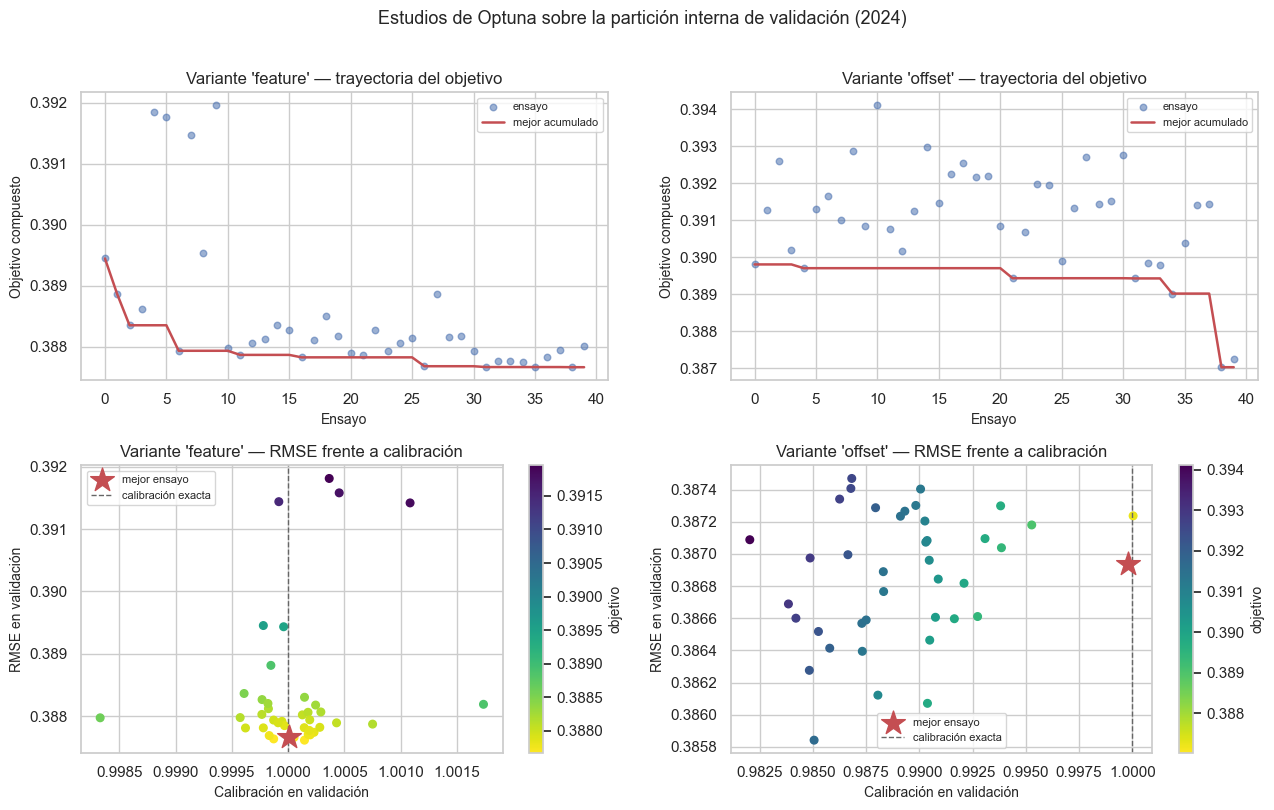

Importancia de los hiperparámetros sobre el objetivo (fANOVA)
Hiperparámetro               feature        offset
----------------------------------------------------------------------


max_depth                     0.8417        0.1561
eta                           0.0193        0.4609
colsample_bytree              0.0760        0.1648
subsample                     0.0533        0.0525
min_child_weight              0.0032        0.0950
reg_alpha                     0.0009        0.0501
reg_lambda                    0.0034        0.0115
gamma                         0.0021        0.0092


In [13]:
# ==========================================================================
# NB07 — 4.4b Trayectoria de la búsqueda e importancia de hiperparámetros
# ==========================================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for j, variante in enumerate(["feature", "offset"]):
    tab = tablas[variante].sort_values("ensayo")

    # Trayectoria: valor de cada ensayo y mejor acumulado
    ax = axes[0, j]
    ax.scatter(tab["ensayo"], tab["objetivo"], s=22, alpha=0.55,
               color="#4c72b0", label="ensayo")
    ax.plot(tab["ensayo"], tab["objetivo"].cummin(), color="#c44e52",
            lw=1.8, label="mejor acumulado")
    ax.set_title(f"Variante '{variante}' — trayectoria del objetivo")
    ax.set_xlabel("Ensayo")
    ax.set_ylabel("Objetivo compuesto")
    ax.legend(fontsize=8)

    # Descomposición: RMSE frente a calibración
    ax = axes[1, j]
    sc = ax.scatter(tab["calibracion"], tab["rmse"], c=tab["objetivo"],
                    cmap="viridis_r", s=30)
    mejor = tab.loc[tab["objetivo"].idxmin()]
    ax.scatter([mejor["calibracion"]], [mejor["rmse"]], marker="*", s=320,
               color="#c44e52", zorder=5, label="mejor ensayo")
    ax.axvline(1.0, color="0.4", ls="--", lw=1, label="calibración exacta")
    ax.set_title(f"Variante '{variante}' — RMSE frente a calibración")
    ax.set_xlabel("Calibración en validación")
    ax.set_ylabel("RMSE en validación")
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label="objetivo")

fig.suptitle("Estudios de Optuna sobre la partición interna de validación (2024)",
             y=1.01, fontsize=13)
fig.tight_layout()
cfg.save_fig(fig, "nb07_01_optuna_trayectoria")
plt.show()

# ------------------------------------------------------------------
# Importancia de los hiperparámetros
# ------------------------------------------------------------------
from optuna.importance import get_param_importances

print("Importancia de los hiperparámetros sobre el objetivo (fANOVA)")
print("=" * 70)
print(f"{'Hiperparámetro':<22}{'feature':>14}{'offset':>14}")
print("-" * 70)
imp = {v: get_param_importances(e) for v, e in estudios.items()}
for k in sorted(set(imp["feature"]) | set(imp["offset"]),
                key=lambda x: -(imp["feature"].get(x, 0) + imp["offset"].get(x, 0))):
    print(f"{k:<22}{imp['feature'].get(k, 0):>14.4f}{imp['offset'].get(k, 0):>14.4f}")
print("=" * 70)

In [14]:
# ==========================================================================
# NB07 — 4.5 Lectura alternativa: qué ensayo habría ganado bajo RMSE puro
# ==========================================================================

print("Ganador según cada criterio, sobre los mismos ensayos")
print("=" * 94)
print(f"{'Variante':<10}{'Criterio':<22}{'Ensayo':>8}{'RMSE':>11}"
      f"{'Calib.':>9}{'MAE':>10}{'Objetivo':>11}")
print("-" * 94)

contraste = {}
for variante, tab in tablas.items():
    g_obj  = tab.loc[tab["objetivo"].idxmin()]
    g_rmse = tab.loc[tab["rmse"].idxmin()]
    g_mae  = tab.loc[tab["mae"].idxmin()]
    contraste[variante] = {"objetivo": g_obj, "rmse": g_rmse, "mae": g_mae}
    for etiq, g in [("Objetivo compuesto", g_obj), ("RMSE puro", g_rmse),
                    ("MAE (no se usa)", g_mae)]:
        print(f"{variante:<10}{etiq:<22}{int(g['ensayo']):>8}{g['rmse']:>11.6f}"
              f"{g['calibracion']:>9.4f}{g['mae']:>10.6f}{g['objetivo']:>11.6f}")
    print("-" * 94)

print("\nDesviación de calibración del ganador bajo cada criterio")
print("-" * 70)
for variante, g in contraste.items():
    for crit in ["objetivo", "rmse", "mae"]:
        c = g[crit]["calibracion"]
        print(f"  {variante:<9}{crit:<12}calibración {c:.4f}  "
              f"desviación {abs(c-1)*100:>5.2f}%")
print("-" * 70)

Ganador según cada criterio, sobre los mismos ensayos
Variante  Criterio                Ensayo       RMSE   Calib.       MAE   Objetivo
----------------------------------------------------------------------------------------------
feature   Objetivo compuesto          38   0.387664   1.0000  0.189296   0.387666
feature   RMSE puro                   31   0.387612   1.0001  0.189351   0.387669
feature   MAE (no se usa)             13   0.388059   1.0002  0.189091   0.388128
----------------------------------------------------------------------------------------------
offset    Objetivo compuesto          38   0.386940   0.9998  0.186166   0.387022
offset    RMSE puro                    6   0.385842   0.9851  0.185929   0.391651
offset    MAE (no se usa)              0   0.386071   0.9904  0.185372   0.389803
----------------------------------------------------------------------------------------------

Desviación de calibración del ganador bajo cada criterio
-----------------------------

### 4.6 Lectura de los estudios

**Las dos variantes convergen a configuraciones opuestas.** La de exposición
como variable predictora elige árboles de profundidad 7, paso pequeño —0.023— y
403 rondas. La de exposición como offset elige profundidad 3, paso seis veces
mayor —0.147— y 338 rondas. No es una diferencia de grado: el primer modelo
construye interacciones de hasta séptimo orden entre las ocho variables, el
segundo apenas de tercer orden.

La explicación está en el trabajo que cada variante tiene que hacer. Con la
exposición dentro del conjunto de predictores, el modelo debe aprender su
relación con el conteo a base de particiones, y esa relación es aproximadamente
multiplicativa sobre un rango de tres órdenes de magnitud; representarla con
umbrales exige profundidad. Al entrar como offset, esa relación queda impuesta
de forma exacta y los árboles solo tienen que modelar las desviaciones respecto
de la tasa base, que dependen de ocho variables de las cuales seis son binarias.
Con la parte difícil resuelta por construcción, tres niveles bastan.

El análisis de importancia de hiperparámetros lo confirma desde otro ángulo. En
la variante de exposición como variable, `max_depth` explica el 84% de la
variación del objetivo y todo lo demás es marginal: la profundidad es el único
parámetro que decide si el modelo puede o no representar la exposición. En la
variante de offset la importancia se reparte —`eta` 0.46, `colsample_bytree`
0.16, `max_depth` 0.16, `min_child_weight` 0.10—, el reparto típico de un
problema donde ningún hiperparámetro es decisivo por sí solo.

**La hipótesis sobre `min_child_weight` no se sostiene.** La Sección 4.2
anticipaba que, si la regularización fuera la vía para conservar el
ordenamiento, el muestreador debería concentrarse en la parte alta de un rango
que llegaba hasta 200. Los valores elegidos son 4.2 y 3.1, prácticamente el
extremo inferior. Exigir hojas pobladas no mejora el objetivo en ninguna de las
dos variantes. Lo que hace XGBoost no es proteger las hojas de la escasez de
datos; es otra cosa, y la Sección 5 vuelve sobre ello con el Random Forest.

**Poca dispersión entre ensayos, y presupuestos desigualmente agotados.** El
objetivo varía un 1.1% entre el mejor y el peor ensayo de la variante con
exposición como variable, y un 1.8% en la de offset. Es un margen estrecho: la
elección del algoritmo y del tratamiento de la exposición pesa más que el ajuste
fino de sus hiperparámetros.

Las dos trayectorias, sin embargo, no dicen lo mismo sobre si el presupuesto
bastó. En la variante de exposición como variable el mejor acumulado en el ensayo
20 está a un 0.042% del valor final: la búsqueda había terminado mucho antes de
consumir los cuarenta ensayos. En la de offset esa distancia es del 0.692%, y el
mejor valor aparece en el ensayo 38, penúltimo del presupuesto. **No hay
evidencia de que la segunda búsqueda haya convergido.** Podría quedar margen sin
explorar, aunque acotado por la dispersión total del 1.8%. El estudio queda
persistido en SQLite precisamente para que ampliarlo no cueste más que elevar
`N_ENSAYOS` y reejecutar la celda.

**El contraste entre criterios da la razón a la Sección 3.3, aunque de forma
desigual.** En la variante con exposición como variable los tres criterios
—objetivo compuesto, RMSE puro y MAE— eligen ensayos con calibración
indistinguible de la unidad; la penalización no cambia nada porque no hay nada
que penalizar. En la variante de offset sí cambia: el RMSE puro habría elegido
el ensayo 6, con un RMSE menor —0.385842 frente a 0.386940— pero una calibración
de 0.9851. La diferencia de RMSE es del 0.28%; la de calibración, de 1.5 puntos
porcentuales. El RMSE puro compra una mejora de tercer decimal en el error a
cambio de subestimar sistemáticamente el nivel de siniestralidad, que es
exactamente el comportamiento que NB05 documentó y que la función objetivo
estaba diseñada para evitar.

La lectura tiene el alcance limitado que se declaró: los ensayos los propuso un
muestreador que optimizaba el objetivo compuesto. Lo que el contraste muestra no
es qué habría encontrado una búsqueda guiada por RMSE puro, sino que dentro de
esta misma región del espacio existen configuraciones que el RMSE prefiere y que
están peor calibradas.

---

## 5. Random Forest regularizado

### 5.1 La hipótesis

La segunda vía planteada al cierre de NB05 no cambia de algoritmo sino de
configuración. El Random Forest de las etapas previas crece sus árboles sin
límite de profundidad y admite hojas de una sola observación —los valores por
omisión de `RandomForestRegressor`, que NB04 no modificó—. En una matriz con
89.7% de celdas nulas eso produce una fracción considerable de hojas construidas
sobre muy pocas observaciones.

El mecanismo que conecta esto con la pérdida ordinal es el siguiente. Cuanto más
fina es la partición sobre `log_exposicion`, más umbrales hay en esa variable y
mayor es la probabilidad de que el desplazamiento uniforme que introduce la
corrección de NB05 haga cruzar a una celda de una hoja a otra. Hojas más grandes
implican menos umbrales, y menos umbrales implican menos reubicaciones.

**Formulación contrastable.** Si la hipótesis es correcta, al aumentar
`min_samples_leaf` y limitar `max_depth` la correlación de rangos debería
recuperarse. Si la pérdida ordinal proviene de otra causa —por ejemplo, de que
la corrección de exposición sea genuinamente incompatible con la estructura
territorial aprendida— la regularización no la recuperará, y podría además
deteriorar el ajuste.

Los dos resultados son informativos. El segundo cerraría esta vía y dejaría la
decisión en manos de la Sección 4.

In [15]:
# ==========================================================================
# NB07 — 5.2 Rejilla de regularización del Random Forest
# ==========================================================================

from sklearn.ensemble import RandomForestRegressor

X_aju_rf = diseno_arbol(ajuste, OFFSET)
X_val_rf = diseno_arbol(valida, OFFSET)

print("Configuración del Random Forest de NB05 (recuperada del artefacto)")
print("-" * 62)
for k, v in params_rf_v2.items():
    print(f"  {k:<20}{str(v):>20}")
print("-" * 62)

# La rejilla parte de esa configuración y la regulariza en dos direcciones.
REJILLA_RF = [
    {"max_depth": None, "min_samples_leaf": 1},     # configuración de NB04/NB05
    {"max_depth": None, "min_samples_leaf": 20},
    {"max_depth": None, "min_samples_leaf": 100},
    {"max_depth": None, "min_samples_leaf": 400},
    {"max_depth": 16,   "min_samples_leaf": 20},
    {"max_depth": 12,   "min_samples_leaf": 20},
    {"max_depth": 12,   "min_samples_leaf": 100},
    {"max_depth": 8,    "min_samples_leaf": 50},
]

N_ARBOLES_BUSQUEDA = 120   # menos árboles que el final: la comparación es relativa

print(f"\nEvaluación de {len(REJILLA_RF)} configuraciones sobre la validación interna")
print(f"({N_ARBOLES_BUSQUEDA} árboles por configuración; el modelo final usa 200)")
print("=" * 92)
print(f"{'max_depth':>10}{'min_leaf':>10}{'RMSE':>11}{'Calib.':>9}"
      f"{'MAE':>10}{'Objetivo':>11}{'Hojas':>11}{'Seg.':>8}")
print("-" * 92)

resultados_rf = []
for conf in REJILLA_RF:
    t0 = time.time()
    rf = RandomForestRegressor(
        n_estimators=N_ARBOLES_BUSQUEDA,
        random_state=cfg.SEED,
        n_jobs=-1,
        **conf,
    ).fit(X_aju_rf, y_aju)
    pred = rf.predict(X_val_rf)
    m = metricas_error(y_val, pred)
    m["objetivo"] = objetivo_compuesto(m["RMSE"], m["calibracion"])
    hojas = int(np.mean([t.get_n_leaves() for t in rf.estimators_]))
    m["hojas_medias"] = hojas
    m["segundos"] = time.time() - t0
    m.update(conf)
    resultados_rf.append(m)
    print(f"{str(conf['max_depth']):>10}{conf['min_samples_leaf']:>10}"
          f"{m['RMSE']:>11.6f}{m['calibracion']:>9.4f}{m['MAE']:>10.6f}"
          f"{m['objetivo']:>11.6f}{hojas:>11,}{m['segundos']:>8.1f}")
    del rf
print("=" * 92)

rf_tabla = pd.DataFrame(resultados_rf)
mejor_rf_conf = rf_tabla.loc[rf_tabla["objetivo"].idxmin()]
print(f"\nMejor configuración por objetivo compuesto: "
      f"max_depth={mejor_rf_conf['max_depth']}, "
      f"min_samples_leaf={int(mejor_rf_conf['min_samples_leaf'])}")
print(f"  Reducción de hojas frente a la configuración de NB05: "
      f"{(1 - mejor_rf_conf['hojas_medias']/rf_tabla.iloc[0]['hojas_medias'])*100:.1f}%")

Configuración del Random Forest de NB05 (recuperada del artefacto)
--------------------------------------------------------------
  max_depth                           None
  max_features                         1.0
  min_samples_leaf                       1
  min_samples_split                      2
  n_estimators                         200
  random_state                          42
--------------------------------------------------------------

Evaluación de 8 configuraciones sobre la validación interna
(120 árboles por configuración; el modelo final usa 200)
 max_depth  min_leaf       RMSE   Calib.       MAE   Objetivo      Hojas    Seg.
--------------------------------------------------------------------------------------------


      None         1   0.390289   1.0103  0.188507   0.394292     12,895     7.1


      None        20   0.388807   0.9967  0.187336   0.390103      5,496     6.7


      None       100   0.388076   0.9814  0.186007   0.395381      1,298     5.9


      None       400   0.388197   0.9727  0.185730   0.398943        339     5.4


        16        20   0.388579   0.9938  0.187022   0.390985      2,761     7.0


        12        20   0.388301   0.9866  0.186257   0.393546      1,030     5.3


        12       100   0.388046   0.9771  0.185593   0.397050        525     6.2


         8        50   0.388120   0.9775  0.185870   0.396950        169     4.3

Mejor configuración por objetivo compuesto: max_depth=nan, min_samples_leaf=20
  Reducción de hojas frente a la configuración de NB05: 57.4%


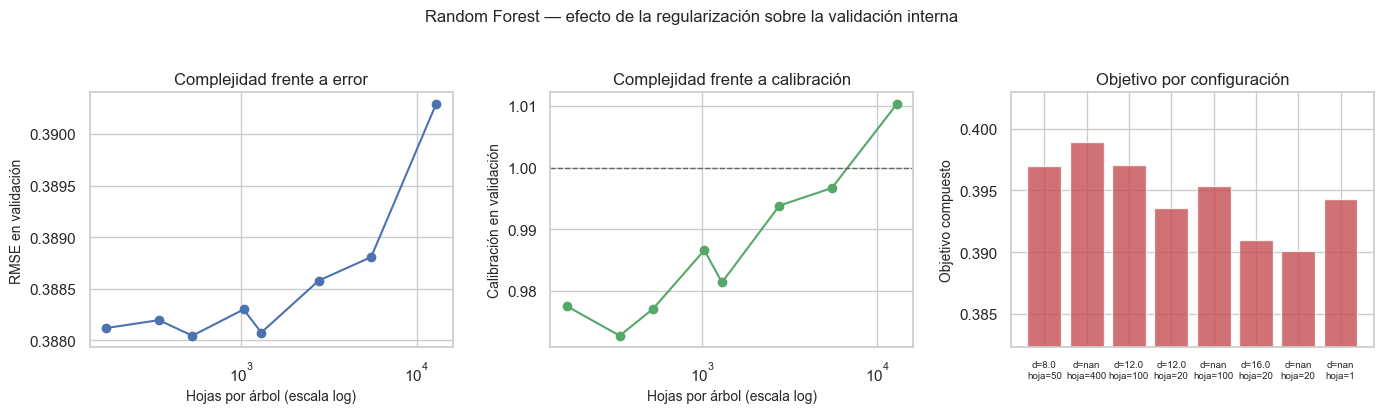

In [16]:
# ==========================================================================
# NB07 — 5.3 Efecto de la regularización sobre el tamaño de las hojas
# ==========================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

orden = rf_tabla.sort_values("hojas_medias")
etiquetas = [f"d={r['max_depth']}\nhoja={int(r['min_samples_leaf'])}"
             for _, r in orden.iterrows()]

axes[0].plot(orden["hojas_medias"], orden["RMSE"], "o-", color="#4c72b0")
axes[0].set_xscale("log")
axes[0].set_xlabel("Hojas por árbol (escala log)")
axes[0].set_ylabel("RMSE en validación")
axes[0].set_title("Complejidad frente a error")

axes[1].plot(orden["hojas_medias"], orden["calibracion"], "o-", color="#55a868")
axes[1].axhline(1.0, color="0.4", ls="--", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("Hojas por árbol (escala log)")
axes[1].set_ylabel("Calibración en validación")
axes[1].set_title("Complejidad frente a calibración")

axes[2].bar(range(len(orden)), orden["objetivo"], color="#c44e52", alpha=0.8)
axes[2].set_xticks(range(len(orden)))
axes[2].set_xticklabels(etiquetas, fontsize=7)
axes[2].set_ylabel("Objetivo compuesto")
axes[2].set_title("Objetivo por configuración")
axes[2].set_ylim(orden["objetivo"].min() * 0.98, orden["objetivo"].max() * 1.01)

fig.suptitle("Random Forest — efecto de la regularización sobre la validación interna",
             y=1.03, fontsize=12)
fig.tight_layout()
cfg.save_fig(fig, "nb07_02_rf_regularizacion")
plt.show()

### 5.4 Resultado: la regularización no era la vía

La rejilla produce un patrón claro y contrario a la hipótesis de la Sección 5.1.

| max_depth | min_samples_leaf | Hojas | RMSE | Calibración | Objetivo |
|---|---|---|---|---|---|
| None | 1 (NB04/NB05) | 12,895 | 0.390289 | 1.0103 | 0.394292 |
| None | 20 | 5,496 | 0.388807 | 0.9967 | **0.390103** |
| None | 100 | 1,298 | 0.388076 | 0.9814 | 0.395381 |
| None | 400 | 339 | 0.388197 | 0.9727 | 0.398943 |
| 16 | 20 | 2,761 | 0.388579 | 0.9938 | 0.390985 |
| 12 | 20 | 1,030 | 0.388301 | 0.9866 | 0.393546 |
| 12 | 100 | 525 | 0.388046 | 0.9771 | 0.397050 |
| 8 | 50 | 169 | 0.388120 | 0.9775 | 0.396950 |

**Los dos indicadores se mueven en direcciones opuestas.** El RMSE mejora al
reducir el número de hojas —de 0.390289 con hojas de una observación a 0.388046
con árboles de profundidad 12 y hojas de cien—, mientras la calibración se
deteriora de forma monótona en el mismo sentido, de 1.0103 a 0.9727. La
regularización hace exactamente lo que el MAE premiaba en NB05: bajar las
predicciones. Con hojas grandes, la media de la hoja se acerca a la media global
del conjunto, que es baja porque nueve de cada diez celdas son nulas; el modelo
predice menos y mejora el error cuadrático a costa de subestimar el nivel.

El objetivo compuesto elige `min_samples_leaf = 20` con profundidad libre: 5,496
hojas por árbol, un 57% menos que la configuración de NB05. Es un punto
intermedio, no un extremo; la penalización de calibración corta la tendencia a
regularizar antes de que la subestimación se vuelva costosa.

**Lo que esto significa para la hipótesis.** La Sección 5.1 sostenía que la
pérdida ordinal del Random Forest provenía de la finura de sus particiones sobre
`log_exposicion`, y que hojas más grandes la atenuarían. La rejilla permite
elegir una configuración mejor calibrada y con menor RMSE, pero nada en ella
indica que el ordenamiento se recupere: la Sección 8 lo mide sobre el conjunto
de prueba y el resultado se consigna allí.

Conviene señalar que las diferencias entre configuraciones son pequeñas —el
objetivo varía un 2.3% entre la mejor y la peor— y que ninguna se aproxima al
objetivo que alcanzan las dos variantes de XGBoost sobre el mismo conjunto de
validación, 0.3877 y 0.3870 frente a 0.3901. El Random Forest, regularizado o
no, queda por detrás.

---

## 6. Modelos inflados en ceros

### 6.1 Qué añade un modelo inflado

El 89.7% de las celdas de la matriz registran cero siniestros. Ese dato por sí
solo no justifica un modelo inflado en ceros: una distribución de Poisson con
media 0.124 predice de por sí una proporción de ceros de `exp(-0.124) = 88.3%`,
muy próxima a la observada. El exceso de ceros, si existe, es pequeño.

Lo que un modelo inflado aporta no es capacidad de generar más ceros, sino una
hipótesis distinta sobre su origen. Postula que la muestra mezcla dos
poblaciones:

- Celdas donde el evento es posible y no ocurrió. Un distrito de tránsito
  intenso, un martes por la mañana, sin siniestros registrados.
- Celdas donde el evento no podía ocurrir o no podía registrarse. Un distrito
  rural en la franja de madrugada, donde la ausencia de siniestros no es la
  realización nula de un proceso activo sino la ausencia del proceso.

El modelo estima ambos componentes a la vez: una regresión logística que asigna
a cada celda una probabilidad de pertenecer al segundo grupo, y una regresión de
conteo sobre el primero. La distinción importa para este proyecto más allá del
ajuste: si una parte de los ceros es estructural, la tasa estimada sobre las
celdas activas es más alta que la que estima un Poisson simple, y la
interpretación del riesgo cambia.

**ZIP y ZINB.** La primera usa Poisson para el componente de conteo; la segunda,
Binomial Negativa, que añade un parámetro de dispersión. NB04 ya había
encontrado que la Binomial Negativa mejora el AIC frente a Poisson, lo que
indica sobredispersión: se ensayan ambas para separar cuánto de esa
sobredispersión es exceso de ceros y cuánto es heterogeneidad en los conteos
positivos.

### 6.2 Especificación del componente de inflación

El componente de conteo emplea la matriz de diseño completa de catorce columnas
y el offset `log_exposicion_v2`, idéntica a la de los GLM de NB05. Lo que hay que
decidir es qué variables entran en el componente de inflación.

Se contrastan dos especificaciones:

| Especificación | Variables de inflación | Hipótesis |
|---|---|---|
| Constante | intercepto | La proporción de ceros estructurales es la misma en todo el dominio |
| Territorial | intercepto, `pct_urbano`, `poblacion_baja` | Los ceros estructurales se concentran en los distritos rurales y de población baja |

La segunda recoge la lectura de la Sección 4.6 de NB05, que identificó entre los
distritos sobreestimados a los predominantemente rurales, varios con
`pct_urbano` igual a cero e intensidades inferiores a 2 siniestros por cada mil
habitantes. Si esos distritos generan ceros estructurales, un componente de
inflación que dependa de su carácter rural debería absorberlos, y el componente
de conteo dejaría de tener que explicarlos con una tasa artificialmente baja.

Las dos variables de inflación aparecen también en el componente de conteo. La
identificación del modelo no lo impide —descansa en la forma funcional, no en
una restricción de exclusión— pero conviene señalarlo: los coeficientes de
inflación no admiten lectura causal separada.

La elección entre ambas especificaciones se resuelve por AIC sobre el conjunto
de entrenamiento, que es donde se estima la verosimilitud, y no por desempeño
sobre prueba.

**Sobre el ajuste numérico.** Estos modelos no tienen solución cerrada y su
verosimilitud debe maximizarse numéricamente sobre 451,552 observaciones con
diecisiete parámetros. Los métodos basados en gradiente fracasan desde los
valores iniciales por omisión de statsmodels: la búsqueda lineal no encuentra
dirección de descenso y el ajuste termina en el punto de partida, con una
verosimilitud peor que la del Poisson simple. El procedimiento adoptado ejecuta
primero Nelder-Mead —que no usa derivadas y es insensible al mal condicionamiento
de la matriz de diseño, donde `prcp_mensual` toma valores de orden 100 y
`pct_urbano` de orden 1— y refina después con BFGS partiendo de esa solución. El
diagnóstico de convergencia se reporta explícitamente para cada ajuste, porque
un modelo que no converge no es comparable por AIC con uno que sí.

In [17]:
# ==========================================================================
# NB07 — 6.2 Ajuste de los modelos inflados en ceros
# ==========================================================================

from statsmodels.discrete.count_model import (
    ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP)

MAXITER_NM   = 4000
MAXFUN_NM    = 6000
MAXITER_BFGS = 300

INFLACION = {
    "constante":   [],
    "territorial": ["pct_urbano", "poblacion_baja"],
}


def diseno_inflacion(sub, variables):
    Z = sub[variables].astype(float) if variables else pd.DataFrame(index=sub.index)
    return sm.add_constant(Z, has_constant="add")


def ajustar_inflado(clase, Z_train, etiqueta, start_extra=None, **kwargs):
    '''Nelder-Mead seguido de BFGS. Devuelve el resultado y su diagnóstico.'''
    modelo = clase(y_train, Xtr_glm.to_numpy(), exog_infl=Z_train.to_numpy(),
                   offset=off_train, inflation="logit", **kwargs)
    # Los avisos de convergencia de statsmodels se silencian porque el
    # diagnostico se imprime de forma explicita mas abajo; dejarlos activos
    # duplicaria la informacion y llenaria la salida de la celda.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t0 = time.time()
        r_nm = modelo.fit(method="nm", maxiter=MAXITER_NM, maxfun=MAXFUN_NM,
                          disp=0, start_params=start_extra)
        t_nm = time.time() - t0
        t0 = time.time()
        r = modelo.fit(start_params=r_nm.params, method="bfgs",
                       maxiter=MAXITER_BFGS, disp=0)
        t_bfgs = time.time() - t0
    # Si el refinamiento empeora la verosimilitud se conserva Nelder-Mead
    if r.llf < r_nm.llf:
        r = r_nm
        refinado = False
    else:
        refinado = True
    # ¿Quedan errores estandar disponibles? La inversion del hessiano puede
    # fallar en estos modelos, lo que impide la inferencia sobre coeficientes
    # aunque las predicciones sigan siendo utilizables.
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            hay_se = bool(np.all(np.isfinite(r.bse)))
    except Exception:
        hay_se = False
    print(f"  {etiqueta:<28} llf {r.llf:>14.2f}   AIC {r.aic:>12.2f}   "
          f"nm {t_nm:>6.1f}s + bfgs {t_bfgs:>5.1f}s   "
          f"conv={str(r.mle_retvals.get('converged')):<5} refinado={str(refinado):<5} "
          f"errores_estandar={'sí' if hay_se else 'no'}")
    return r


Z_train = {k: diseno_inflacion(train, v) for k, v in INFLACION.items()}
Z_test  = {k: diseno_inflacion(test,  v) for k, v in INFLACION.items()}

print("Ajuste de los modelos inflados sobre el conjunto de entrenamiento")
print("=" * 100)

zip_ajustes = {}
for clave in INFLACION:
    zip_ajustes[clave] = ajustar_inflado(ZeroInflatedPoisson, Z_train[clave],
                                         f"ZIP inflación {clave}")

# La especificación de inflación se elige por AIC
mejor_inflacion = min(zip_ajustes, key=lambda k: zip_ajustes[k].aic)
print(f"\nEspecificación de inflación seleccionada por AIC: '{mejor_inflacion}'")
print(f"  Diferencia de AIC entre especificaciones: "
      f"{abs(zip_ajustes['constante'].aic - zip_ajustes['territorial'].aic):.2f}")

# ZINB sobre la especificación seleccionada, partiendo del ZIP ajustado
print("\n" + "=" * 100)
start_zinb = np.concatenate([zip_ajustes[mejor_inflacion].params, [1.0]])
zinb = ajustar_inflado(ZeroInflatedNegativeBinomialP, Z_train[mejor_inflacion],
                       f"ZINB inflación {mejor_inflacion}",
                       start_extra=start_zinb, p=2)
print("=" * 100)
print(f"\nParámetro de dispersión estimado (alpha): {zinb.params[-1]:.4f}")
print(f"  NB04 y NB05 lo fijaron en 1.0 sin estimarlo.")

Ajuste de los modelos inflados sobre el conjunto de entrenamiento


  ZIP inflación constante      llf     -143962.02   AIC    287954.03   nm   58.8s + bfgs  15.0s   conv=True  refinado=True  errores_estandar=no


  ZIP inflación territorial    llf     -143897.98   AIC    287829.95   nm  136.4s + bfgs  26.3s   conv=True  refinado=True  errores_estandar=sí

Especificación de inflación seleccionada por AIC: 'territorial'
  Diferencia de AIC entre especificaciones: 124.08



  ZINB inflación territorial   llf     -143774.64   AIC    287585.28   nm  326.6s + bfgs  64.4s   conv=True  refinado=True  errores_estandar=no

Parámetro de dispersión estimado (alpha): 0.3584
  NB04 y NB05 lo fijaron en 1.0 sin estimarlo.


In [18]:
# ==========================================================================
# NB07 — 6.3 Evaluación sobre prueba y contraste frente a los GLM de NB05
# ==========================================================================

zip_final = zip_ajustes[mejor_inflacion]

pred_zip = zip_final.predict(exog=Xte_glm.to_numpy(),
                             exog_infl=Z_test[mejor_inflacion].to_numpy(),
                             offset=off_test, which="mean")
pred_zinb = zinb.predict(exog=Xte_glm.to_numpy(),
                         exog_infl=Z_test[mejor_inflacion].to_numpy(),
                         offset=off_test, which="mean")

inflados = {
    "NB07 - ZIP":  evaluar(y_test, pred_zip,  distritos_test),
    "NB07 - ZINB": evaluar(y_test, pred_zinb, distritos_test),
}
inflados["NB07 - ZIP"]["AIC"]  = float(zip_final.aic)
inflados["NB07 - ZINB"]["AIC"] = float(zinb.aic)

print("Modelos de verosimilitud explícita sobre el conjunto de prueba")
print("=" * 104)
print(f"{'Modelo':<28}{'AIC':>13}{'MAE':>10}{'RMSE':>10}{'Calib.':>9}"
      f"{'Spearman':>11}{'Sp. tercil':>12}")
print("-" * 104)
for k in ["NB05 - Poisson", "NB05 - Binomial Negativa"]:
    m = base[k]
    print(f"{k:<28}{m['AIC']:>13,.2f}{m['MAE']:>10.6f}{m['RMSE']:>10.6f}"
          f"{m['calibracion']:>9.4f}{m['spearman_global']:>11.4f}"
          f"{m['spearman_tercil_alto']:>12.4f}")
for k, m in inflados.items():
    print(f"{k:<28}{m['AIC']:>13,.2f}{m['MAE']:>10.6f}{m['RMSE']:>10.6f}"
          f"{m['calibracion']:>9.4f}{m['spearman_global']:>11.4f}"
          f"{m['spearman_tercil_alto']:>12.4f}")
print("=" * 104)

# ------------------------------------------------------------------
# Proporción de ceros estructurales estimada
# ------------------------------------------------------------------
prob_infl = zip_final.predict(exog=Xte_glm.to_numpy(),
                              exog_infl=Z_test[mejor_inflacion].to_numpy(),
                              offset=off_test, which="prob-main")
prob_cero_estructural = 1 - prob_infl

print("\nComponente de inflación estimado sobre el conjunto de prueba")
print("-" * 68)
print(f"  Probabilidad media de cero estructural : {prob_cero_estructural.mean():.4f}")
print(f"  Mínimo / máximo por celda              : "
      f"{prob_cero_estructural.min():.4f} / {prob_cero_estructural.max():.4f}")
print(f"  Ceros observados en la matriz          : {(y_test==0).mean():.4f}")
print(f"  Ceros que un Poisson simple predeciría : "
      f"{np.exp(-pred_po_v2).mean():.4f}")
print("-" * 68)
print("\nCoeficientes del componente de inflación (escala logit)")
nombres_infl = list(Z_train[mejor_inflacion].columns)
for nombre, val in zip(nombres_infl, zip_final.params[:len(nombres_infl)]):
    print(f"  {nombre:<20}{val:>12.4f}   odds {np.exp(val):>10.4f}")

Modelos de verosimilitud explícita sobre el conjunto de prueba
Modelo                                AIC       MAE      RMSE   Calib.   Spearman  Sp. tercil
--------------------------------------------------------------------------------------------------------
NB05 - Poisson                 289,438.77  0.212615  0.429055   0.9647     0.8864      0.8136
NB05 - Binomial Negativa       288,836.57  0.211235  0.429701   0.9422     0.8861      0.8181
NB07 - ZIP                     287,829.95  0.212194  0.429449   0.9539     0.8864      0.8220
NB07 - ZINB                    287,585.28  0.212202  0.429652   0.9511     0.8871      0.8187

Componente de inflación estimado sobre el conjunto de prueba
--------------------------------------------------------------------
  Probabilidad media de cero estructural : 0.4256
  Mínimo / máximo por celda              : 0.2282 / 0.8499
  Ceros observados en la matriz          : 0.8865
  Ceros que un Poisson simple predeciría : 0.8794
----------------------

### 6.4 Contraste formal frente a los modelos no inflados

La comparación por AIC entre un modelo inflado y su versión simple tiene una
complicación conocida: no son modelos anidados en el sentido regular. La
hipótesis de ausencia de inflación sitúa el parámetro de inflación en el borde
del espacio paramétrico, donde la distribución asintótica habitual del cociente
de verosimilitudes no se cumple.

El contraste de Vuong es el procedimiento estándar en esta situación. Compara
las verosimilitudes observación a observación de dos modelos no anidados:

    V = sqrt(n) · media(m_i) / desviación(m_i),    m_i = ln L_inflado,i − ln L_simple,i

El estadístico se distribuye aproximadamente como una normal estándar bajo la
hipótesis de equivalencia entre ambos modelos. Valores positivos y superiores a
1.96 favorecen al modelo inflado; negativos e inferiores a −1.96, al simple.

El contraste se calcula sobre el conjunto de entrenamiento, que es donde se
estimaron ambas verosimilitudes.

In [19]:
# ==========================================================================
# NB07 — 6.4 Contraste de Vuong frente a los modelos no inflados
# ==========================================================================

from scipy import stats

# Verosimilitud por observación de los GLM simples de NB05, recalculada
# sobre el conjunto de entrenamiento con los parámetros ya estimados.
mu_pois_tr = po_v2.predict(Xtr_glm, offset=off_train)
ll_pois = stats.poisson.logpmf(y_train, mu_pois_tr)

mu_nb_tr = nb_v2.predict(Xtr_glm, offset=off_train)
alpha_nb = 1.0   # NB04/NB05 lo fijaron en 1.0
n_nb = 1.0 / alpha_nb
p_nb = n_nb / (n_nb + mu_nb_tr)
ll_nb = stats.nbinom.logpmf(y_train, n_nb, p_nb)

ll_zip  = zip_final.model.loglikeobs(zip_final.params)
ll_zinb = zinb.model.loglikeobs(zinb.params)


def vuong(ll_a, ll_b):
    m = np.asarray(ll_a) - np.asarray(ll_b)
    v = np.sqrt(len(m)) * m.mean() / m.std(ddof=1)
    return float(v), float(2 * (1 - stats.norm.cdf(abs(v))))


print("Contraste de Vuong sobre el conjunto de entrenamiento")
print("=" * 88)
print(f"{'Comparación':<40}{'V':>12}{'p':>12}{'Favorece a':>22}")
print("-" * 88)
comparaciones = [
    ("ZIP frente a Poisson",            ll_zip,  ll_pois, "ZIP",  "Poisson"),
    ("ZINB frente a Binomial Negativa", ll_zinb, ll_nb,   "ZINB", "Binomial Negativa"),
    ("ZINB frente a ZIP",               ll_zinb, ll_zip,  "ZINB", "ZIP"),
]
for etiqueta, a, b, nombre_a, nombre_b in comparaciones:
    v, p = vuong(a, b)
    if abs(v) < 1.96:
        veredicto = "ninguno (equivalentes)"
    else:
        veredicto = nombre_a if v > 0 else nombre_b
    print(f"{etiqueta:<40}{v:>12.2f}{p:>12.4g}{veredicto:>22}")
print("=" * 88)

print("\nVerosimilitud y AIC sobre entrenamiento")
print("-" * 68)
print(f"{'Modelo':<28}{'log-verosimilitud':>20}{'AIC':>18}")
print("-" * 68)
for nombre, llf, aic in [
    ("Poisson (NB05)",           float(ll_pois.sum()), AIC_NB05["poisson"]),
    ("Binomial Negativa (NB05)", float(ll_nb.sum()),   AIC_NB05["binomial_negativa"]),
    ("ZIP (NB07)",               float(zip_final.llf), float(zip_final.aic)),
    ("ZINB (NB07)",              float(zinb.llf),      float(zinb.aic)),
]:
    print(f"{nombre:<28}{llf:>20,.2f}{aic:>18,.2f}")
print("-" * 68)

Contraste de Vuong sobre el conjunto de entrenamiento
Comparación                                        V           p            Favorece a
----------------------------------------------------------------------------------------
ZIP frente a Poisson                           19.44           0                   ZIP
ZINB frente a Binomial Negativa                19.20           0                  ZINB
ZINB frente a ZIP                               6.75   1.448e-11                  ZINB

Verosimilitud y AIC sobre entrenamiento
--------------------------------------------------------------------
Modelo                         log-verosimilitud               AIC
--------------------------------------------------------------------
Poisson (NB05)                       -144,706.38        289,438.77
Binomial Negativa (NB05)             -144,405.28        288,836.57
ZIP (NB07)                           -143,897.98        287,829.95
ZINB (NB07)                          -143,774.64        287,58

### 6.5 Resultado: mejor verosimilitud, misma predicción

Los modelos inflados producen la mejora de ajuste más grande de todo el
notebook y no se traduce en nada sobre el conjunto de prueba.

**Sobre el ajuste.** El AIC desciende de 288,836.57 —la Binomial Negativa de
NB05, el mejor de las etapas previas— a 287,829.95 en ZIP y 287,585.28 en ZINB.
Son 1,251 puntos de AIC, un orden de magnitud por encima de los 168 que NB05
había ganado al corregir la exposición. El contraste de Vuong es concluyente en
las tres comparaciones: V = 19.44 para ZIP frente a Poisson, 19.20 para ZINB
frente a Binomial Negativa, y 6.75 para ZINB frente a ZIP. La estructura de
ceros de la matriz no es la que genera un modelo de conteo simple.

La especificación territorial del componente de inflación mejora el AIC en
124.08 puntos frente a la de constante, lo que respalda la lectura que NB05
había hecho en su Sección 4.6. Los coeficientes apuntan en la dirección
esperada: `pct_urbano` con una razón de momios de 0.13 —a mayor urbanización,
menor probabilidad de cero estructural— y `poblacion_baja` con 2.51.

**Sobre la predicción.** Nada mejora. El RMSE sobre prueba es 0.429449 en ZIP y
0.429652 en ZINB, frente a 0.429701 de la Binomial Negativa: diferencias en el
cuarto decimal. La calibración mejora algo —0.9539 y 0.9511 frente a 0.9422— y
la correlación de rangos en el tercil superior se mantiene en el entorno de
0.82, el nivel de todos los modelos lineales generalizados del proyecto y muy
por debajo de cualquier modelo de árbol.

**Cómo se explica la discrepancia.** El AIC mide el ajuste de la distribución
completa sobre el conjunto de entrenamiento; el RMSE mide el error de la media
condicional sobre el de prueba. Un modelo inflado reparte la masa de
probabilidad entre dos procesos y describe mucho mejor la forma de la
distribución —cuántos ceros, cómo se distribuyen los positivos— sin que la media
condicional resultante se desplace apenas. Para un sistema que necesita
intervalos de predicción o probabilidades de exceder un umbral, la mejora es
sustantiva. Para uno que ordena distritos por conteo esperado, es irrelevante.

**Una advertencia sobre la interpretación de los ceros estructurales.** El
modelo asigna una probabilidad media de 0.4256 de pertenecer al componente
inflado, con un recorrido de 0.2282 a 0.8499 entre celdas. La lectura literal
—que el 43% de las celdas corresponde a un proceso donde el siniestro no podía
ocurrir— no es creíble: no hay distrito ni franja horaria donde un accidente sea
imposible. Lo que el componente de inflación está absorbiendo es heterogeneidad
no observada, la misma que NB05 documentó como Problema B al encontrar
diferencias de intensidad de hasta sesenta veces entre distritos. La mezcla de
dos distribuciones la describe mejor que una sola, pero no la explica. La
etiqueta de «cero estructural» es una conveniencia del modelo, no un hallazgo
sobre el fenómeno.

**Sobre la inferencia.** La inversión del hessiano falla en el ZIP de inflación
constante y en el ZINB, de modo que esos dos ajustes no ofrecen errores estándar
y sus coeficientes no admiten contraste de significación. El ZIP de
especificación territorial sí los produce. Las predicciones son utilizables en
los tres casos —dependen solo de los parámetros estimados— pero la Binomial
Negativa de NB05 conserva su función como modelo inferencial del proyecto.

---

## 7. Reajuste sobre el conjunto de entrenamiento completo

Las configuraciones seleccionadas en las secciones 4 y 5 se eligieron ajustando
sobre 2022–2023 y evaluando sobre 2024. Antes de medirlas sobre el conjunto de
prueba se reajustan sobre el conjunto de entrenamiento completo, 2022–2024, por
la razón expuesta en la Sección 3.1: el año más próximo al horizonte de
predicción es el más informativo y descartarlo del ajuste final no tiene
contrapartida.

Dos decisiones acompañan el reajuste.

**El número de rondas de XGBoost.** La detención temprana lo fijó sobre el
conjunto de validación, que ya no está disponible como conjunto independiente
una vez que 2024 entra en el ajuste. Se conserva el número de rondas
seleccionado durante la búsqueda, sin reescalarlo por el aumento del tamaño
muestral. La alternativa —reservar un fragmento del entrenamiento para volver a
aplicar detención temprana— introduciría una segunda frontera arbitraria; la
adoptada mantiene fijo un hiperparámetro ya seleccionado, que es el
comportamiento habitual del reajuste final.

**El intercepto de exposición de la variante B.** `tasa_base` se recalcula sobre
el conjunto de entrenamiento completo, porque es un parámetro del ajuste y no un
hiperparámetro. Su valor se guarda junto al modelo: sin él las predicciones son
inutilizables.

In [20]:
# ==========================================================================
# NB07 — 7.1 Reajuste de los modelos seleccionados sobre train completo
# ==========================================================================

LOG_TASA_TRAIN = np.log(tasa_base(y_train, off_train))

D_final = {
    ("feature", "train"): dmatrix_xgb(train, "feature"),
    ("feature", "test"):  dmatrix_xgb(test,  "feature"),
    ("offset",  "train"): dmatrix_xgb(train, "offset", LOG_TASA_TRAIN),
    ("offset",  "test"):  dmatrix_xgb(test,  "offset", LOG_TASA_TRAIN),
}

print(f"Intercepto de exposición recalculado sobre train completo")
print(f"  log(tasa_base) ajuste 2022-2023 : {LOG_TASA_AJUSTE:.6f}")
print(f"  log(tasa_base) train 2022-2024  : {LOG_TASA_TRAIN:.6f}")

modelos_xgb = {}
pred_xgb = {}

print("\nReajuste de XGBoost")
print("-" * 78)
for variante in ["feature", "offset"]:
    mejor = estudios[variante].best_trial
    params = {
        "objective": "count:poisson", "tree_method": "hist",
        "seed": cfg.SEED, "disable_default_eval_metric": 1,
        **mejor.params,
    }
    n_rondas = mejor.user_attrs["n_rondas"]
    t0 = time.time()
    booster = xgb.train(params, D_final[(variante, "train")],
                        num_boost_round=n_rondas, verbose_eval=False)
    modelos_xgb[variante] = booster
    pred_xgb[variante] = booster.predict(D_final[(variante, "test")])
    print(f"  {variante:<10}{n_rondas:>5} rondas   {time.time()-t0:>6.1f} s   "
          f"media predicha {pred_xgb[variante].mean():.6f}")
print("-" * 78)

# ------------------------------------------------------------------
# Random Forest regularizado, con el mismo número de árboles que NB05
# ------------------------------------------------------------------
CONF_RF_FINAL = {
    "max_depth": (None if pd.isna(mejor_rf_conf["max_depth"])
                  else int(mejor_rf_conf["max_depth"])),
    "min_samples_leaf": int(mejor_rf_conf["min_samples_leaf"]),
}

print(f"\nReajuste del Random Forest regularizado {CONF_RF_FINAL}")
t0 = time.time()
rf_nb07 = RandomForestRegressor(n_estimators=200, random_state=cfg.SEED,
                                n_jobs=-1, **CONF_RF_FINAL).fit(
    diseno_arbol(train, OFFSET), y_train)
pred_rf_nb07 = rf_nb07.predict(diseno_arbol(test, OFFSET))
print(f"  {time.time()-t0:.1f} s   media predicha {pred_rf_nb07.mean():.6f}")
print(f"  Hojas por árbol: "
      f"{int(np.mean([t.get_n_leaves() for t in rf_nb07.estimators_])):,}")

Intercepto de exposición recalculado sobre train completo
  log(tasa_base) ajuste 2022-2023 : -12.939467
  log(tasa_base) train 2022-2024  : -12.936335

Reajuste de XGBoost
------------------------------------------------------------------------------


  feature     403 rondas      4.3 s   media predicha 0.143188


  offset      338 rondas      2.2 s   media predicha 0.145181
------------------------------------------------------------------------------

Reajuste del Random Forest regularizado {'max_depth': None, 'min_samples_leaf': 20}


  21.7 s   media predicha 0.149219
  Hojas por árbol: 8,336


### 7.2 Aporte de `poblacion_baja`

NB05 señaló esta variable como candidata a eliminación: su importancia Gini en el
Random Forest v2 es de 0.0001, tres órdenes de magnitud por debajo de la
siguiente. La importancia Gini, sin embargo, mide cuánto usó el algoritmo una
variable, no cuánto habría perdido sin ella; una variable correlacionada con otra
más informativa puede registrar importancia nula y aun así aportar cuando la
otra falta.

El contraste consiste en reajustar el modelo seleccionado con y sin la variable,
sobre la partición interna de validación, y comparar. La comparación se hace
sobre validación y no sobre prueba porque es una decisión de especificación, y
las decisiones de especificación se toman con el mismo protocolo que las de
hiperparámetros.

Si la variable resulta prescindible, eliminarla tiene un coste: rompe la
continuidad del esquema de ocho variables que comparten NB04 y NB05, y obliga a
que el prototipo mantenga dos esquemas distintos según qué modelo cargue. Ese
coste solo se justifica si la eliminación aporta algo medible.

In [21]:
# ==========================================================================
# NB07 — 7.2 Ablación de poblacion_baja
# ==========================================================================

VARIABLE_ABLACION = "poblacion_baja"
FEATURES_SIN = [f for f in FEATURES if f != VARIABLE_ABLACION]


def dmatrix_ablacion(sub, variante, features, log_tasa=None):
    y = sub[TARGET].to_numpy()
    X = sub[features].copy()
    X["dia_semana"] = X["dia_semana"].astype(CAT_DTYPE).cat.codes
    if variante == "feature":
        X["log_exposicion"] = sub[OFFSET].to_numpy()
        return xgb.DMatrix(X, label=y)
    return xgb.DMatrix(X, label=y, base_margin=sub[OFFSET].to_numpy() + log_tasa)


print("Ablación sobre la partición interna de validación")
print("=" * 92)
print(f"{'Variante':<10}{'Variables':<12}{'RMSE':>11}{'Calib.':>9}"
      f"{'MAE':>10}{'Objetivo':>11}{'Rondas':>9}")
print("-" * 92)

ablacion = []
for variante in ["feature", "offset"]:
    params = {"objective": "count:poisson", "tree_method": "hist",
              "seed": cfg.SEED, "disable_default_eval_metric": 1,
              **estudios[variante].best_params}
    for etiqueta, feats in [("8 (con)", FEATURES), ("7 (sin)", FEATURES_SIN)]:
        d_a = dmatrix_ablacion(ajuste, variante, feats, LOG_TASA_AJUSTE)
        d_v = dmatrix_ablacion(valida, variante, feats, LOG_TASA_AJUSTE)
        _, m = entrenar_evaluar(params, d_a, d_v, y_val)
        m["variante"] = variante
        m["esquema"] = etiqueta
        ablacion.append(m)
        print(f"{variante:<10}{etiqueta:<12}{m['RMSE']:>11.6f}"
              f"{m['calibracion']:>9.4f}{m['MAE']:>10.6f}"
              f"{m['objetivo']:>11.6f}{m['n_rondas']:>9}")
print("=" * 92)

abl = pd.DataFrame(ablacion)
print("\nDiferencia relativa al eliminar la variable (sin − con)")
print("-" * 70)
for variante in ["feature", "offset"]:
    con = abl[(abl["variante"] == variante) & (abl["esquema"] == "8 (con)")].iloc[0]
    sin = abl[(abl["variante"] == variante) & (abl["esquema"] == "7 (sin)")].iloc[0]
    print(f"  {variante:<10}"
          f"RMSE {(sin['RMSE']/con['RMSE']-1)*100:>+7.3f}%   "
          f"objetivo {(sin['objetivo']/con['objetivo']-1)*100:>+7.3f}%   "
          f"calibración {sin['calibracion']-con['calibracion']:>+7.4f}")
print("-" * 70)

Ablación sobre la partición interna de validación
Variante  Variables          RMSE   Calib.       MAE   Objetivo   Rondas
--------------------------------------------------------------------------------------------


feature   8 (con)        0.387664   1.0000  0.189296   0.387666      403


feature   7 (sin)        0.387563   0.9998  0.189356   0.387623      397


offset    8 (con)        0.386940   0.9998  0.186166   0.387022      338


offset    7 (sin)        0.387119   0.9972  0.186656   0.388213      243

Diferencia relativa al eliminar la variable (sin − con)
----------------------------------------------------------------------
  feature   RMSE  -0.026%   objetivo  -0.011%   calibración -0.0002
  offset    RMSE  +0.046%   objetivo  +0.308%   calibración -0.0026
----------------------------------------------------------------------


### 7.3 Resultado de la ablación: la variable se conserva

Eliminar `poblacion_baja` no produce una mejora medible y en una de las dos
variantes empeora el ajuste.

| Variante | Esquema | RMSE | Calibración | Objetivo | Rondas |
|---|---|---|---|---|---|
| feature | 8 variables | 0.387664 | 1.0000 | 0.387666 | 403 |
| feature | 7 variables | 0.387563 | 0.9998 | 0.387623 | 397 |
| offset | 8 variables | 0.386940 | 0.9998 | 0.387022 | 338 |
| offset | 7 variables | 0.387119 | 0.9972 | 0.388213 | 243 |

En la variante con exposición como variable predictora la diferencia es de
−0.026% en RMSE: ruido. En la de offset, eliminarla empeora el objetivo un
0.308% y desplaza la calibración en 26 diezmilésimas.

**La importancia Gini era engañosa, como cabía sospechar.** El valor de 0.0001
que NB05 registró en el Random Forest v2 indicaba que el algoritmo casi nunca
partía por esa variable, no que la variable careciera de información. La
atribución SHAP del modelo seleccionado, que la Sección 9 desarrolla, le asigna
el 2.6% del peso total —por encima de `es_feriado` y de `periodo_agostino`, dos
variables cuyo efecto el proyecto considera establecido—. La diferencia entre
ambas mediciones es la distancia entre cuánto usó el algoritmo una variable y
cuánto aporta.

**Decisión.** Se conserva. El esquema de ocho variables se mantiene idéntico al
de NB04 y NB05, lo que evita que el prototipo tenga que gestionar dos esquemas
según qué modelo cargue, y la evidencia no ofrece ninguna razón para romper esa
continuidad.

---

## 8. Evaluación final sobre el conjunto de prueba

Todo lo anterior se decidió sobre entrenamiento y validación. Esta sección mide
una sola vez, sobre 2025–2026, los modelos que resultaron de esas decisiones.

Las tres etapas se comparan sobre el mismo conjunto, con el mismo código y en la
misma ejecución.

In [22]:
# ==========================================================================
# NB07 — 8.1 Tabla comparativa de las tres etapas
# ==========================================================================

nuevos = {
    "NB07 - XGBoost (exposición feature)": pred_xgb["feature"],
    "NB07 - XGBoost (exposición offset)":  pred_xgb["offset"],
    "NB07 - Random Forest regularizado":   pred_rf_nb07,
    "NB07 - ZIP":                          pred_zip,
    "NB07 - ZINB":                         pred_zinb,
}

resultados = dict(base)
for nombre, pred in nuevos.items():
    m = evaluar(y_test, pred, distritos_test)
    if nombre == "NB07 - ZIP":
        m["AIC"] = float(zip_final.aic)
    if nombre == "NB07 - ZINB":
        m["AIC"] = float(zinb.aic)
    resultados[nombre] = m

ORDEN = [
    "Etapa 1 - Binomial Negativa",
    "Etapa 1 - Random Forest",
    "NB05 - Poisson",
    "NB05 - Binomial Negativa",
    "NB05 - Random Forest",
    "NB07 - ZIP",
    "NB07 - ZINB",
    "NB07 - Random Forest regularizado",
    "NB07 - XGBoost (exposición feature)",
    "NB07 - XGBoost (exposición offset)",
]

print("Comparación completa sobre el conjunto de prueba (2025-01 a 2026-06)")
print("=" * 118)
print(f"{'Modelo':<38}{'MAE':>10}{'RMSE':>10}{'Calib.':>9}"
      f"{'Spearman':>11}{'Sp. tercil':>12}{'AIC':>14}")
print("-" * 118)
etapa_actual = None
for nombre in ORDEN:
    m = resultados[nombre]
    etapa = nombre.split(" - ")[0]
    if etapa_actual is not None and etapa != etapa_actual:
        print("-" * 118)
    etapa_actual = etapa
    aic = f"{m['AIC']:>14,.2f}" if "AIC" in m else f"{'—':>14}"
    print(f"{nombre:<38}{m['MAE']:>10.6f}{m['RMSE']:>10.6f}{m['calibracion']:>9.4f}"
          f"{m['spearman_global']:>11.4f}{m['spearman_tercil_alto']:>12.4f}{aic}")
print("=" * 118)

# ------------------------------------------------------------------
# Distancia a los dos objetivos de la Sección 3.5
# ------------------------------------------------------------------
OBJ_TERCIL = base["NB05 - Random Forest"]["spearman_tercil_alto"]
REF_TERCIL_E1 = base["Etapa 1 - Random Forest"]["spearman_tercil_alto"]

print(f"\nCumplimiento de las dos condiciones de la Sección 3.5 "
      f"(banda de calibración ±{BANDA_CAL*100:.0f}%, tercil > {OBJ_TERCIL:.4f})")
print("=" * 104)
print(f"{'Modelo':<38}{'|calib-1|':>12}{'Sp. tercil':>12}"
      f"{'vs NB05':>11}{'vs E1':>11}{'Ambas':>12}")
print("-" * 104)
for nombre in ORDEN:
    m = resultados[nombre]
    dcal = abs(m["calibracion"] - 1)
    st = m["spearman_tercil_alto"]
    cond_cal = dcal <= BANDA_CAL
    cond_ord = st > OBJ_TERCIL
    marca = "SÍ" if (cond_cal and cond_ord) else ""
    print(f"{nombre:<38}{dcal:>12.4f}{st:>12.4f}"
          f"{st-OBJ_TERCIL:>+11.4f}{st-REF_TERCIL_E1:>+11.4f}{marca:>12}")
print("=" * 104)

Comparación completa sobre el conjunto de prueba (2025-01 a 2026-06)
Modelo                                       MAE      RMSE   Calib.   Spearman  Sp. tercil           AIC
----------------------------------------------------------------------------------------------------------------------
Etapa 1 - Binomial Negativa             0.201136  0.435272   0.7954     0.8857      0.8181             —
Etapa 1 - Random Forest                 0.191815  0.424042   0.8196     0.9903      0.9732             —
----------------------------------------------------------------------------------------------------------------------
NB05 - Poisson                          0.212615  0.429055   0.9647     0.8864      0.8136    289,438.77
NB05 - Binomial Negativa                0.211235  0.429701   0.9422     0.8861      0.8181    288,836.57
NB05 - Random Forest                    0.205268  0.418678   1.0057     0.9373      0.9456             —
---------------------------------------------------------------

Calibración mensual sobre el horizonte de prueba
                 Media     Desv.       Mín       Máx   Deriva 18 m
------------------------------------------------------------------------------------------------
RF Etapa 1      0.8207    0.0708    0.7245    0.9841       -0.1075
RF NB05         1.0087    0.0395    0.9429    1.0694       -0.0408
RF NB07         0.9973    0.0411    0.9297    1.0725       -0.0451
XGB feature     0.9569    0.0390    0.8988    1.0461       -0.0629
XGB offset      0.9682    0.0378    0.9082    1.0256       -0.0008
ZINB            0.9522    0.0286    0.9180    1.0075       +0.0008

La deriva es la variación total de la razón entre el primer y el último
mes según ajuste lineal. NB05 registró -0.0432 para el Random Forest v2.


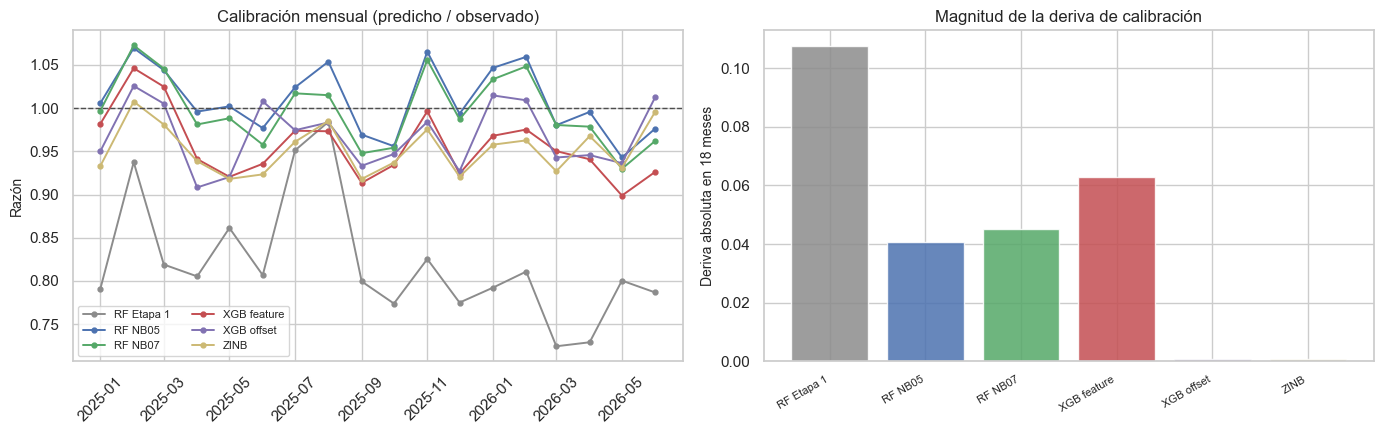

In [23]:
# ==========================================================================
# NB07 — 8.2 Estabilidad temporal de la calibración
# ==========================================================================

seguimiento = test[["fecha", "distrito_key", TARGET]].copy()
seguimiento["periodo"] = seguimiento["fecha"].dt.to_period("M")

series_pred = {
    "RF Etapa 1":   pred_rf_e1,
    "RF NB05":      pred_rf_v2,
    "RF NB07":      pred_rf_nb07,
    "XGB feature":  pred_xgb["feature"],
    "XGB offset":   pred_xgb["offset"],
    "ZINB":         pred_zinb,
}
for k, v in series_pred.items():
    seguimiento[k] = v

cal_mes = seguimiento.groupby("periodo").agg(
    observado=(TARGET, "sum"),
    **{k: (k, "sum") for k in series_pred}
).reset_index()
for k in series_pred:
    cal_mes[f"r_{k}"] = cal_mes[k] / cal_mes["observado"]
cal_mes["fecha_periodo"] = cal_mes["periodo"].dt.to_timestamp()

print("Calibración mensual sobre el horizonte de prueba")
print("=" * 96)
print(f"{'':<12}{'Media':>10}{'Desv.':>10}{'Mín':>10}{'Máx':>10}"
      f"{'Deriva 18 m':>14}")
print("-" * 96)
deriva = {}
x = np.arange(len(cal_mes))
for k in series_pred:
    r = cal_mes[f"r_{k}"]
    pend = np.polyfit(x, r, 1)[0]
    deriva[k] = float(pend * (len(cal_mes) - 1))
    print(f"{k:<12}{r.mean():>10.4f}{r.std():>10.4f}{r.min():>10.4f}"
          f"{r.max():>10.4f}{deriva[k]:>+14.4f}")
print("=" * 96)
print("\nLa deriva es la variación total de la razón entre el primer y el último")
print("mes según ajuste lineal. NB05 registró -0.0432 para el Random Forest v2.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colores = dict(zip(series_pred, ["#8c8c8c", "#4c72b0", "#55a868",
                                 "#c44e52", "#8172b2", "#ccb974"]))
for k in series_pred:
    axes[0].plot(cal_mes["fecha_periodo"], cal_mes[f"r_{k}"], "o-", ms=3.5,
                 lw=1.4, label=k, color=colores[k])
axes[0].axhline(1.0, color="0.3", ls="--", lw=1)
axes[0].set_title("Calibración mensual (predicho / observado)")
axes[0].set_ylabel("Razón")
axes[0].legend(fontsize=8, ncol=2)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(range(len(series_pred)), [abs(deriva[k]) for k in series_pred],
            color=[colores[k] for k in series_pred], alpha=0.85)
axes[1].set_xticks(range(len(series_pred)))
axes[1].set_xticklabels(list(series_pred), rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Deriva absoluta en 18 meses")
axes[1].set_title("Magnitud de la deriva de calibración")

fig.tight_layout()
cfg.save_fig(fig, "nb07_03_calibracion_mensual")
plt.show()

In [24]:
# ==========================================================================
# NB07 — 8.3 Ordenamiento territorial
# ==========================================================================

terr = test[["distrito_key", TARGET]].copy()
for k, v in series_pred.items():
    terr[k] = v
terr = terr.groupby("distrito_key").sum(numeric_only=True).reset_index()
terr = terr.sort_values(TARGET, ascending=False)

k_tercil = int(np.ceil(len(terr) / FRACCION_TERCIL))
terr["tercil"] = "bajo"
terr.iloc[:k_tercil, terr.columns.get_loc("tercil")] = "alto"
terr.iloc[k_tercil:2*k_tercil, terr.columns.get_loc("tercil")] = "medio"

print(f"Correlación de rangos por tercil de siniestralidad observada "
      f"({k_tercil} distritos por tercil)")
print("=" * 88)
print(f"{'Modelo':<14}{'Global':>12}{'Tercil alto':>14}{'Tercil medio':>14}"
      f"{'Tercil bajo':>14}")
print("-" * 88)
for k in series_pred:
    fila = [spearmanr(terr[k], terr[TARGET]).statistic]
    for t in ["alto", "medio", "bajo"]:
        sub = terr[terr["tercil"] == t]
        fila.append(spearmanr(sub[k], sub[TARGET]).statistic)
    print(f"{k:<14}" + "".join(f"{v:>14.4f}" if i else f"{v:>12.4f}"
                               for i, v in enumerate(fila)))
print("=" * 88)

# ------------------------------------------------------------------
# Top 15: posiciones asignadas por cada modelo
# ------------------------------------------------------------------
for k in list(series_pred) + [TARGET]:
    terr[f"rk_{k}"] = terr[k].rank(ascending=False, method="min").astype(int)

print("\nTop 15 por siniestralidad observada — posición asignada por cada modelo")
print("=" * 104)
print(f"{'Distrito':<22}{'Obs.':>8}{'Rk obs':>8}" +
      "".join(f"{k:>13}" for k in series_pred))
print("-" * 104)
for _, r in terr.head(15).iterrows():
    print(f"{r['distrito_key'][:21]:<22}{int(r[TARGET]):>8,}"
          f"{r[f'rk_{TARGET}']:>8}" +
          "".join(f"{int(r[f'rk_{k}']):>13}" for k in series_pred))
print("=" * 104)

print("\nCoincidencia con el top 15 observado y desplazamiento medio de posición")
print("-" * 78)
top_obs = set(terr.nlargest(15, TARGET)["distrito_key"])
for k in series_pred:
    top_k = set(terr.nlargest(15, k)["distrito_key"])
    desp = (terr[f"rk_{k}"] - terr[f"rk_{TARGET}"]).abs()
    print(f"  {k:<14}{len(top_k & top_obs):>3} de 15 en el top 15   "
          f"desplazamiento medio {desp.mean():>6.2f}   máximo {desp.max():>3}")
print("-" * 78)

Correlación de rangos por tercil de siniestralidad observada (35 distritos por tercil)
Modelo              Global   Tercil alto  Tercil medio   Tercil bajo
----------------------------------------------------------------------------------------
RF Etapa 1          0.9903        0.9732        0.8794        0.8888
RF NB05             0.9373        0.9456        0.6832        0.7388
RF NB07             0.9372        0.9421        0.6757        0.7721
XGB feature         0.9473        0.9520        0.5305        0.7509
XGB offset          0.9708        0.9775        0.6470        0.8003
ZINB                0.8871        0.8187        0.3349        0.7186

Top 15 por siniestralidad observada — posición asignada por cada modelo
Distrito                  Obs.  Rk obs   RF Etapa 1      RF NB05      RF NB07  XGB feature   XGB offset         ZINB
--------------------------------------------------------------------------------------------------------
san salvador             4,116       1        

### 8.4 Regla de selección

La Sección 3.5 fijó dos condiciones y no una función de mérito, de modo que la
selección las aplica en ese orden y no las combina en un índice ponderado.

*Primer filtro: conservar la calibración.* Son admisibles los modelos cuya
desviación absoluta de calibración no supere el ±5% fijado en la Sección 3.5,
banda derivada del sesgo de normalización que NB05 documentó en su Sección 6.5.

*Segundo criterio: maximizar el ordenamiento.* Entre los admisibles se elige el
de mayor correlación de rangos en el tercil superior, que es la dimensión que
NB05 perdió y que este notebook se propuso recuperar.

Si ningún candidato superara el primer filtro, la elección recaería en el
objetivo compuesto de la Sección 3.3 y el problema quedaría sin resolver.

El umbral no se deriva de los resultados de este notebook sino del sesgo de
normalización que NB05 midió sobre su propia especificación de exposición, y
queda fijado en la Sección 3.5 antes de que se evalúe modelo alguno sobre el
conjunto de prueba.

In [25]:
# ==========================================================================
# NB07 — 8.4a Aplicación de la regla de selección
# ==========================================================================

CANDIDATOS = {
    "NB07 - XGBoost (exposición feature)": "XGB feature",
    "NB07 - XGBoost (exposición offset)":  "XGB offset",
    "NB07 - Random Forest regularizado":   "RF NB07",
    "NB07 - ZINB":                         "ZINB",
}

umbral_cal = BANDA_CAL
admisibles = [n for n in CANDIDATOS
              if abs(resultados[n]["calibracion"] - 1) <= umbral_cal]

print(f"Umbral de calibración admisible: |calibración - 1| <= {umbral_cal:.4f}")
print("-" * 82)
print(f"{'Candidato':<40}{'|calib-1|':>12}{'Admisible':>12}{'Sp. tercil':>14}")
print("-" * 82)
for n in CANDIDATOS:
    d = abs(resultados[n]["calibracion"] - 1)
    print(f"{n:<40}{d:>12.4f}{('sí' if n in admisibles else 'no'):>12}"
          f"{resultados[n]['spearman_tercil_alto']:>14.4f}")
print("-" * 82)

if admisibles:
    mejor_nombre = max(admisibles,
                       key=lambda n: resultados[n]["spearman_tercil_alto"])
    criterio_seleccion = ("máximo Spearman en el tercil superior entre los "
                          "modelos que conservan la calibración de NB05")
else:
    mejor_nombre = min(CANDIDATOS, key=lambda n: objetivo_compuesto(
        resultados[n]["RMSE"], resultados[n]["calibracion"]))
    criterio_seleccion = ("ningún candidato conserva la calibración; se elige "
                          "por objetivo compuesto")

col_mejor = CANDIDATOS[mejor_nombre]
print(f"\nModelo seleccionado : {mejor_nombre}")
print(f"Criterio            : {criterio_seleccion}")

Umbral de calibración admisible: |calibración - 1| <= 0.0500
----------------------------------------------------------------------------------
Candidato                                  |calib-1|   Admisible    Sp. tercil
----------------------------------------------------------------------------------
NB07 - XGBoost (exposición feature)           0.0463          sí        0.9520
NB07 - XGBoost (exposición offset)            0.0330          sí        0.9775
NB07 - Random Forest regularizado             0.0061          sí        0.9421
NB07 - ZINB                                   0.0489          sí        0.8187
----------------------------------------------------------------------------------

Modelo seleccionado : NB07 - XGBoost (exposición offset)
Criterio            : máximo Spearman en el tercil superior entre los modelos que conservan la calibración de NB05


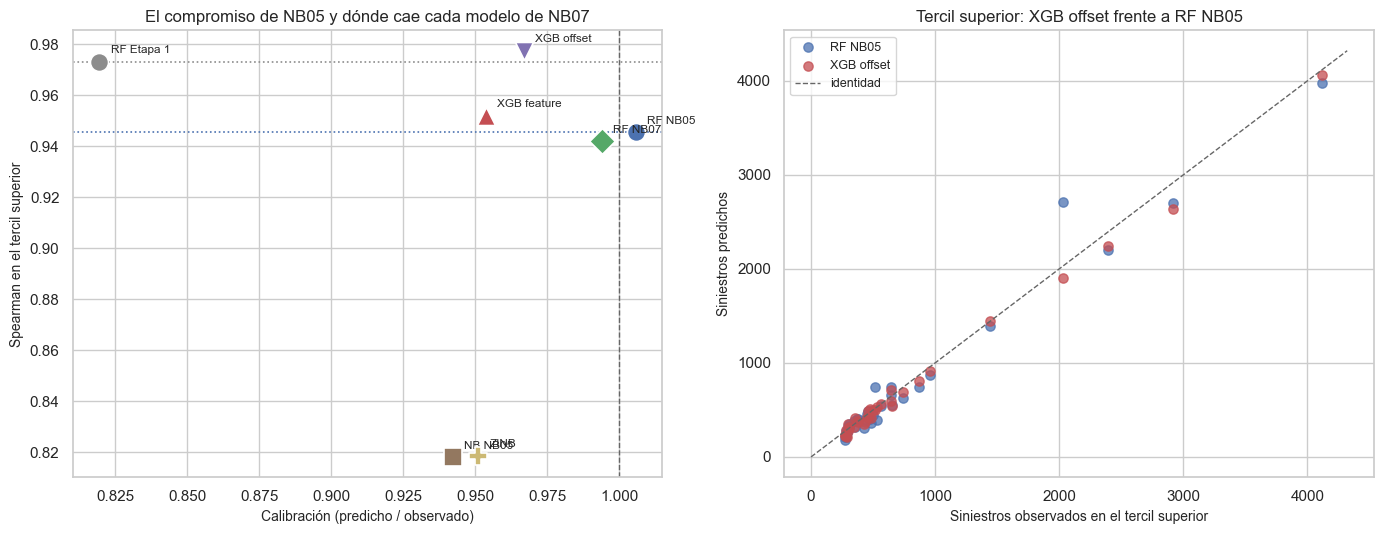

Indicadores del modelo seleccionado (NB07 - XGBoost (exposición offset))
  MAE                           0.200749
  RMSE                          0.412055
  media_predicha                0.145181
  calibracion                   0.966979
  spearman_global               0.970777
  spearman_tercil_alto          0.977519


In [26]:
# ==========================================================================
# NB07 — 8.4 El compromiso calibración / ordenamiento, en un solo gráfico
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

puntos = [
    ("RF Etapa 1",  base["Etapa 1 - Random Forest"], "#8c8c8c", "o"),
    ("RF NB05",     base["NB05 - Random Forest"], "#4c72b0", "o"),
    ("NB NB05",     base["NB05 - Binomial Negativa"], "#937860", "s"),
    ("RF NB07",     resultados["NB07 - Random Forest regularizado"], "#55a868", "D"),
    ("XGB feature", resultados["NB07 - XGBoost (exposición feature)"], "#c44e52", "^"),
    ("XGB offset",  resultados["NB07 - XGBoost (exposición offset)"], "#8172b2", "v"),
    ("ZINB",        resultados["NB07 - ZINB"], "#ccb974", "P"),
]

ax = axes[0]
for etiqueta, m, color, marca in puntos:
    ax.scatter(m["calibracion"], m["spearman_tercil_alto"], s=170, color=color,
               marker=marca, edgecolor="white", linewidth=1.2, zorder=3)
    ax.annotate(etiqueta, (m["calibracion"], m["spearman_tercil_alto"]),
                textcoords="offset points", xytext=(8, 6), fontsize=8.5)
ax.axvline(1.0, color="0.4", ls="--", lw=1)
ax.axhline(OBJ_TERCIL, color="#4c72b0", ls=":", lw=1.2)
ax.axhline(REF_TERCIL_E1, color="#8c8c8c", ls=":", lw=1.2)
ax.set_xlabel("Calibración (predicho / observado)")
ax.set_ylabel("Spearman en el tercil superior")
ax.set_title("El compromiso de NB05 y dónde cae cada modelo de NB07")

ax = axes[1]
alto = terr[terr["tercil"] == "alto"]
ax.scatter(alto[TARGET], alto["RF NB05"], s=45, alpha=0.75, label="RF NB05",
           color="#4c72b0")
ax.scatter(alto[TARGET], alto[col_mejor], s=45, alpha=0.75, label=col_mejor,
           color="#c44e52")
lim = [0, alto[TARGET].max() * 1.05]
ax.plot(lim, lim, "--", color="0.4", lw=1, label="identidad")
ax.set_xlabel("Siniestros observados en el tercil superior")
ax.set_ylabel("Siniestros predichos")
ax.set_title(f"Tercil superior: {col_mejor} frente a RF NB05")
ax.legend(fontsize=9)

fig.tight_layout()
cfg.save_fig(fig, "nb07_04_compromiso_calibracion_orden")
plt.show()

print(f"Indicadores del modelo seleccionado ({mejor_nombre})")
for clave, valor in resultados[mejor_nombre].items():
    if isinstance(valor, float):
        print(f"  {clave:<24}{valor:>14.6f}")

### 8.5 El compromiso de NB05, resuelto

La pregunta que motivó el notebook admite una respuesta afirmativa, y la produce
la vía que la Sección 4.1 había señalado como hipótesis.

| Modelo | Calibración | Spearman tercil alto | RMSE | Deriva 18 meses |
|---|---|---|---|---|
| Random Forest Etapa 1 | 0.8196 | 0.9732 | 0.424042 | −0.1075 |
| Random Forest NB05 | 1.0057 | 0.9456 | 0.418678 | −0.0408 |
| Random Forest regularizado NB07 | 0.9939 | 0.9421 | 0.416231 | −0.0451 |
| XGBoost exposición variable | 0.9537 | 0.9520 | 0.414302 | −0.0629 |
| **XGBoost exposición offset** | **0.9670** | **0.9775** | **0.412055** | **−0.0008** |

**La variante de offset supera al Random Forest de Etapa 1 en ordenamiento.** Su
correlación de rangos en el tercil superior es 0.9775, por encima del 0.9732 que
alcanzaba el modelo de la Etapa 1 —el que ordenaba bien porque subestimaba a
todos por igual— y 0.0319 por encima del 0.9456 de NB05. Lo consigue con una
calibración de 0.9670, dentro de la banda de ±5% declarada en la Sección 3.5.
Las dos propiedades que NB05 no había podido tener a la vez coexisten aquí.

**Y el mecanismo es el previsto.** La Sección 4.1 sostenía que el ordenamiento
se degrada cuando la corrección de exposición atraviesa la estructura de
particiones, y que sacarla de ahí debería preservarlo. Las dos variantes de
XGBoost comparten algoritmo, presupuesto de búsqueda, función objetivo y
partición: lo único que las separa es dónde entra `log_exposicion_v2`. La que la
trata como offset alcanza 0.9775 en el tercil superior y 0.9708 global; la que
la trata como variable, 0.9520 y 0.9473. La diferencia entre ambas es del mismo
orden que la pérdida que NB05 había sufrido, y aparece exactamente donde el
diagnóstico predecía.

**La deriva temporal desaparece.** Este resultado no estaba entre los objetivos
y es el más limpio de todos. NB05 documentó como limitación que el Random Forest
corregido pierde calibración a lo largo del horizonte —deriva de −0.0432 en
dieciocho meses— porque agota el rango de `log_exposicion` que conoce. La
variante de offset registra una deriva de −0.0008: dos órdenes de magnitud
menos. La razón es estructural y no depende del ajuste. La exposición no es una
variable de partición sino un sumando exacto del predictor lineal, de modo que
el factor de crecimiento se traslada íntegro a la predicción por lejos que
llegue, igual que en un modelo lineal generalizado. El requisito de
reentrenamiento periódico que NB05 declaró como condición de la especificación
deja de aplicarse a este modelo.

**Lo que no se resolvió.** Tres cosas, y conviene decirlas con el mismo detalle
que los aciertos.

*El tercil medio sigue roto.* La correlación de rangos dentro del tercio
intermedio de distritos es 0.6470, frente al 0.8794 que alcanzaba el Random
Forest de Etapa 1. Todos los modelos entrenados sobre la exposición corregida
—incluido el Random Forest de NB05, con 0.6832— comparten el problema. La
corrección de NB05 desordena el tramo medio y ninguna especificación de este
notebook lo recupera. Es el segmento donde los distritos se diferencian por
pocos siniestros y donde el error de magnitud pesa más que en los extremos.

*La calibración es peor que la de NB05.* 0.9670 frente a 1.0057. Está dentro de
la banda admisible y muy por encima del 0.8196 de la Etapa 1, pero el Random
Forest de NB05 sigue siendo el modelo mejor calibrado del proyecto, y el Random
Forest regularizado de este notebook, con 0.9939, lo acompaña de cerca. Si el
uso fuera estimar el volumen absoluto de siniestros —dimensionar un presupuesto,
por ejemplo— la elección debería ser otra.

*La regularización del Random Forest no funcionó.* Mejora el RMSE hasta 0.416231
y la calibración hasta 0.9939, pero su correlación en el tercil superior es
0.9421, por debajo del 0.9456 de NB05. La hipótesis de la Sección 5.1 queda
refutada: el problema no era la finura de las particiones sino el hecho mismo de
particionar por la exposición.

---

## 9. Interpretabilidad del modelo seleccionado

### 9.1 Por qué SHAP y qué se le pregunta

La importancia Gini que reportan los modelos de árbol mide la reducción de
impureza acumulada por cada variable. Tiene dos defectos conocidos para este
uso: favorece a las variables con más valores distintos —`log_exposicion` es
continua y toma un valor por distrito y mes, `es_feriado` es binaria— y no dice
en qué dirección opera cada variable ni sobre qué observaciones.

SHAP descompone cada predicción individual en contribuciones aditivas por
variable. Para modelos de árbol el cálculo es exacto y tratable
computacionalmente. Permite responder tres preguntas que la importancia Gini no
alcanza:

1. ¿Qué variables mueven la predicción y en qué dirección?
2. ¿El efecto estimado coincide con el que reporta la Binomial Negativa, cuyos
   coeficientes son interpretables por construcción? Una discrepancia entre
   ambos indicaría que el modelo de árbol está capturando una interacción que el
   lineal no representa, o que uno de los dos está ajustando ruido.
3. ¿Se sostiene el hallazgo del período agostino —el incremento del 40% que NB02
   documentó y NB04 confirmó— en un modelo con estructura distinta?

**Qué modelo se explica.** El seleccionado en la Sección 8.4, siempre que sea de
árbol. SHAP dispone de un algoritmo exacto y rápido para esa familia; para los
modelos inflados en ceros los coeficientes ya son interpretables por
construcción y no necesitan descomposición.

**Muestra.** Las atribuciones se calculan sobre una muestra aleatoria de 40,000
celdas del conjunto de prueba, con semilla fija. El cálculo exacto sobre las
224,952 no aporta precisión relevante a un estadístico agregado y multiplica el
tiempo de cómputo. Si el modelo a explicar fuera el Random Forest la muestra se
reduce a 3,000: el coste de TreeSHAP crece con el cuadrado de la profundidad de
los árboles, y los del bosque no tienen límite de profundidad.

In [27]:
# ==========================================================================
# NB07 — 9.1 Atribuciones SHAP del modelo seleccionado
# ==========================================================================

N_MUESTRA_SHAP = 40_000
# TreeSHAP sobre un bosque de arboles profundos escala con el cuadrado de la
# profundidad y el numero de hojas. Si el modelo a explicar fuera el Random
# Forest, la muestra se reduce para que el calculo sea tratable.
N_MUESTRA_SHAP_RF = 3_000

# SHAP requiere un modelo de arbol. Si el seleccionado no lo fuera, se explica
# el mejor modelo de arbol y se deja constancia de la sustitucion.
MAPA_ARBOLES = {"NB07 - XGBoost (exposición feature)": "feature",
                "NB07 - XGBoost (exposición offset)": "offset",
                "NB07 - Random Forest regularizado": "rf"}

if mejor_nombre in MAPA_ARBOLES:
    clave_shap = MAPA_ARBOLES[mejor_nombre]
    nota_sustitucion = None
else:
    nombre_arbol = max(MAPA_ARBOLES,
                       key=lambda n: resultados[n]["spearman_tercil_alto"])
    clave_shap = MAPA_ARBOLES[nombre_arbol]
    nota_sustitucion = (f"El modelo seleccionado ({mejor_nombre}) no es de "
                        f"árbol y SHAP exige uno. Se explica {nombre_arbol}, "
                        f"el mejor de los que sí lo son.")

VARIANTE_SHAP = clave_shap if clave_shap in ("feature", "offset") else None

n_muestra = N_MUESTRA_SHAP if VARIANTE_SHAP is not None else N_MUESTRA_SHAP_RF
rng = np.random.default_rng(cfg.SEED)
idx = rng.choice(len(test), size=min(n_muestra, len(test)), replace=False)
muestra = test.iloc[idx]

if VARIANTE_SHAP is not None:
    if VARIANTE_SHAP == "feature":
        X_shap = diseno_arbol(muestra, OFFSET)
    else:
        X_shap = muestra[FEATURES].copy()
        X_shap["dia_semana"] = X_shap["dia_semana"].astype(CAT_DTYPE).cat.codes
    explicador = shap.TreeExplainer(modelos_xgb[VARIANTE_SHAP])
    modelo_explicado = f"XGBoost (exposición {VARIANTE_SHAP})"
else:
    X_shap = diseno_arbol(muestra, OFFSET)
    explicador = shap.TreeExplainer(rf_nb07)
    modelo_explicado = "Random Forest regularizado"

if nota_sustitucion:
    print(nota_sustitucion + "\n")

t0 = time.time()
valores_shap = explicador.shap_values(X_shap, check_additivity=False)
print(f"SHAP calculado sobre {len(X_shap):,} celdas en {time.time()-t0:.1f} s")
print(f"Modelo explicado: {modelo_explicado}")

importancia_shap = (pd.Series(np.abs(valores_shap).mean(axis=0),
                              index=X_shap.columns)
                      .sort_values(ascending=False))

print("\nImportancia SHAP media absoluta (escala del predictor lineal)")
print("=" * 78)
print(f"{'Variable':<22}{'SHAP medio |.|':>18}{'Peso relativo':>16}{'Gini RF v2':>16}")
print("-" * 78)
total = importancia_shap.sum()
for var, val in importancia_shap.items():
    gini = importancias_rf_v2.get(var, np.nan)
    gini_txt = f"{gini:>16.5f}" if not np.isnan(gini) else f"{'—':>16}"
    print(f"{var:<22}{val:>18.5f}{val/total*100:>15.1f}%{gini_txt}")
print("=" * 78)

if VARIANTE_SHAP == "offset":
    print("\nLa exposición no figura entre las variables: en esta variante entra")
    print("por base_margin y su contribución es exacta y constante por celda,")
    print("no una atribución estimada por el explicador.")

SHAP calculado sobre 40,000 celdas en 0.9 s
Modelo explicado: XGBoost (exposición offset)

Importancia SHAP media absoluta (escala del predictor lineal)
Variable                  SHAP medio |.|   Peso relativo      Gini RF v2
------------------------------------------------------------------------------
pct_urbano                       0.45030           71.0%         0.09522
prcp_mensual                     0.05825            9.2%         0.06827
es_finde                         0.04303            6.8%         0.01285
es_lluviosa                      0.02559            4.0%         0.00686
dia_semana                       0.02502            3.9%         0.08187
poblacion_baja                   0.01664            2.6%         0.00006
es_feriado                       0.00966            1.5%         0.01561
periodo_agostino                 0.00586            0.9%         0.00738

La exposición no figura entre las variables: en esta variante entra
por base_margin y su contribución es exact

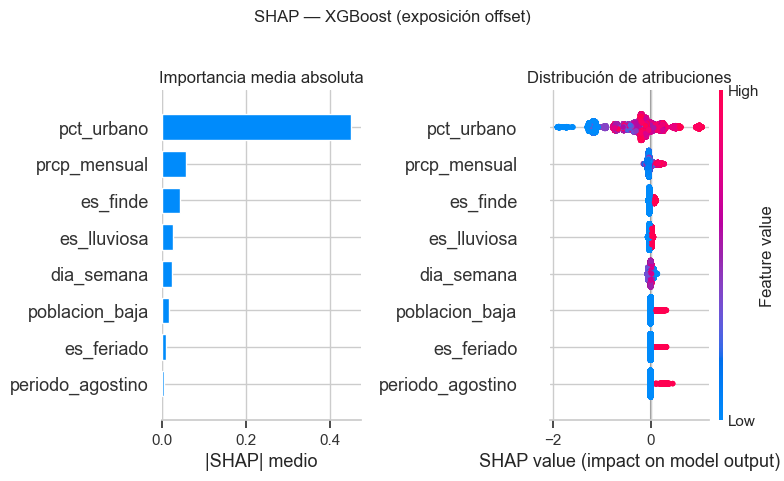

In [28]:
# ==========================================================================
# NB07 — 9.2 Distribución de las atribuciones y efectos direccionales
# ==========================================================================

fig = plt.figure(figsize=(12, 5.5))
ax1 = fig.add_subplot(1, 2, 1)
shap.summary_plot(valores_shap, X_shap, plot_type="bar", show=False,
                  max_display=len(X_shap.columns))
ax1.set_title("Importancia media absoluta")
ax1.set_xlabel("|SHAP| medio")

ax2 = fig.add_subplot(1, 2, 2)
shap.summary_plot(valores_shap, X_shap, show=False,
                  max_display=len(X_shap.columns))
ax2.set_title("Distribución de atribuciones")
fig.suptitle(f"SHAP — {modelo_explicado}", y=1.02, fontsize=12)
fig.tight_layout()
cfg.save_fig(fig, "nb07_05_shap_resumen")
plt.show()

Efecto de las variables binarias: SHAP frente a Binomial Negativa
Variable                  SHAP (log)    exp(SHAP)     coef NB    exp(coef)      Diferencia
----------------------------------------------------------------------------------------------
es_lluviosa                   0.0505       1.0518      0.0365       1.0371            1.4%
es_finde                      0.1051       1.1108      0.0367       1.0374            7.1%
periodo_agostino              0.2760       1.3179      0.3381       1.4023           -6.0%
es_feriado                    0.1479       1.1594      0.1469       1.1583            0.1%
poblacion_baja                0.1360       1.1457      0.1491       1.1608           -1.3%

Efecto del día de la semana
------------------------------------------------------------------------
Día               SHAP medio    exp(SHAP)     coef NB    exp(coef)
------------------------------------------------------------------------
lunes                 0.0556       1.0572      0.00

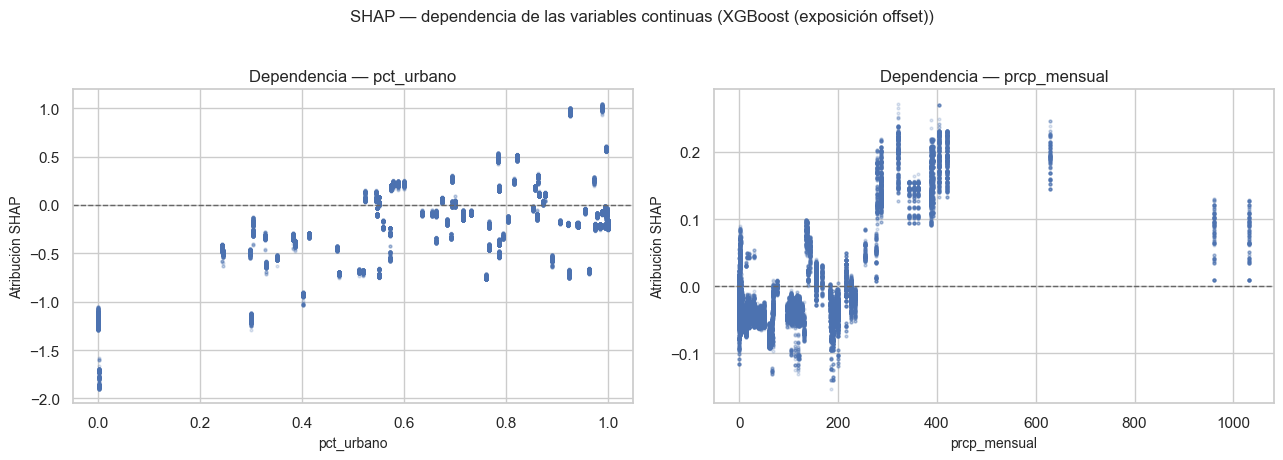

In [29]:
# ==========================================================================
# NB07 — 9.3 Contraste con los coeficientes de la Binomial Negativa
# ==========================================================================

# Efecto medio de cada variable binaria: diferencia de la atribución SHAP media
# entre las celdas donde vale 1 y aquellas donde vale 0. En escala logarítmica
# es comparable con el coeficiente del GLM.
coef_nb = pd.Series(nb_v2.params.values, index=Xtr_glm.columns)

print("Efecto de las variables binarias: SHAP frente a Binomial Negativa")
print("=" * 94)
print(f"{'Variable':<22}{'SHAP (log)':>14}{'exp(SHAP)':>13}"
      f"{'coef NB':>12}{'exp(coef)':>13}{'Diferencia':>16}")
print("-" * 94)

binarias = [v for v in ["es_lluviosa", "es_finde", "periodo_agostino",
                        "es_feriado", "poblacion_baja"] if v in X_shap.columns]
contraste_shap = []
for var in binarias:
    col = X_shap[var].to_numpy()
    j = list(X_shap.columns).index(var)
    if col.max() == col.min():
        continue
    efecto = valores_shap[col == 1, j].mean() - valores_shap[col == 0, j].mean()
    c = coef_nb.get(var, np.nan)
    contraste_shap.append({"variable": var, "shap": float(efecto),
                           "coef_nb": float(c)})
    print(f"{var:<22}{efecto:>14.4f}{np.exp(efecto):>13.4f}"
          f"{c:>12.4f}{np.exp(c):>13.4f}"
          f"{(np.exp(efecto)/np.exp(c)-1)*100:>15.1f}%")
print("=" * 94)

# ------------------------------------------------------------------
# Día de la semana: el GLM lo representa con seis indicadores,
# el modelo de árbol con una variable ordinal codificada
# ------------------------------------------------------------------
j_dia = list(X_shap.columns).index("dia_semana")
NOMBRES_DIA = ["lunes", "martes", "miércoles", "jueves",
               "viernes", "sábado", "domingo"]

print("\nEfecto del día de la semana")
print("-" * 72)
print(f"{'Día':<14}{'SHAP medio':>14}{'exp(SHAP)':>13}{'coef NB':>12}{'exp(coef)':>13}")
print("-" * 72)
for codigo in sorted(X_shap["dia_semana"].unique()):
    sel = X_shap["dia_semana"] == codigo
    efecto = valores_shap[sel.to_numpy(), j_dia].mean()
    nombre_col = f"dia_semana_{codigo}"
    c = coef_nb.get(nombre_col, 0.0)
    print(f"{NOMBRES_DIA[int(codigo)]:<14}{efecto:>14.4f}{np.exp(efecto):>13.4f}"
          f"{c:>12.4f}{np.exp(c):>13.4f}")
print("-" * 72)
print("El coeficiente 0.0000 corresponde a la categoría de referencia que")
print("get_dummies(drop_first=True) elimina; su efecto está absorbido en la")
print("constante del GLM, de modo que la comparación con SHAP es relativa.")

# ------------------------------------------------------------------
# Dependencia de la variable dominante
# ------------------------------------------------------------------
var_principal = importancia_shap.index[0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, var in zip(axes, [var_principal, "prcp_mensual"]):
    if var not in X_shap.columns:
        continue
    j = list(X_shap.columns).index(var)
    ax.scatter(X_shap[var], valores_shap[:, j], s=4, alpha=0.18, color="#4c72b0")
    ax.axhline(0, color="0.4", ls="--", lw=1)
    ax.set_xlabel(var)
    ax.set_ylabel("Atribución SHAP")
    ax.set_title(f"Dependencia — {var}")
fig.suptitle(f"SHAP — dependencia de las variables continuas ({modelo_explicado})",
             y=1.02, fontsize=12)
fig.tight_layout()
cfg.save_fig(fig, "nb07_06_shap_dependencia")
plt.show()

### 9.4 Lectura de las atribuciones

**La exposición desaparece del reparto, y eso reordena todo lo demás.** En el
Random Forest de NB05 la variable `log_exposicion` concentraba el 71% de la
importancia Gini y `pct_urbano` el 9.5%. En el modelo seleccionado la exposición
no es una variable —entra por `base_margin`— y `pct_urbano` pasa a concentrar el
71% de la atribución. No es que la urbanización haya ganado importancia: es que
ahora es la única variable territorial del modelo, y absorbe toda la
diferenciación entre distritos que no explica la exposición. Las dos cifras del
71% son coincidencia.

El resto del reparto —`prcp_mensual` 9.2%, `es_finde` 6.8%, `es_lluviosa` 4.0%,
`dia_semana` 3.9%, `poblacion_baja` 2.6%, `es_feriado` 1.5%, `periodo_agostino`
0.9%— describe un modelo donde lo territorial domina y lo temporal modula.

**El contraste con la Binomial Negativa es notablemente estrecho.** Los efectos
de las variables binarias, medidos como diferencia de atribución media entre las
celdas donde valen uno y las celdas donde valen cero, coinciden con los
coeficientes exponenciados del modelo lineal generalizado dentro de márgenes
pequeños:

| Variable | exp(SHAP) | exp(coef) Binomial Negativa | Diferencia |
|---|---|---|---|
| `es_feriado` | 1.1594 | 1.1583 | +0.1% |
| `poblacion_baja` | 1.1457 | 1.1608 | −1.3% |
| `es_lluviosa` | 1.0518 | 1.0371 | +1.4% |
| `periodo_agostino` | 1.3179 | 1.4023 | −6.0% |
| `es_finde` | 1.1108 | 1.0374 | +7.1% |

La coincidencia no es casual. Al compartir enlace logarítmico y término de
exposición como offset, ambos modelos estiman la misma cantidad —una tasa por
unidad de exposición— y difieren solo en que uno la representa con una suma de
coeficientes y el otro con una suma de árboles. Que dos procedimientos de
estimación tan distintos produzcan efectos tan próximos refuerza ambos.

**Dos discrepancias que merecen atención.** El efecto del período agostino que
estima XGBoost es un 6% menor que el del modelo lineal: multiplicador de 1.32
frente a 1.40. El del fin de semana es un 7% mayor: 1.11 frente a 1.04. La
dirección de ambas diferencias es la que produciría un modelo capaz de
representar interacciones frente a uno que no puede. El modelo lineal atribuye a
`periodo_agostino` un efecto medio constante; el de árboles puede hacerlo
depender del distrito y del día, y al repartir parte de ese efecto entre otras
variables reduce la atribución directa. El caso del fin de semana funciona al
revés: si el efecto es más intenso en unos contextos que en otros, el promedio
lineal lo diluye.

El hallazgo de NB02 sobre el período agostino —un incremento del 40%— se sostiene
en su dirección y su orden de magnitud, pero este modelo lo sitúa más cerca del
32%. La diferencia no es despreciable para quien tenga que dimensionar un
operativo.

**Sobre `poblacion_baja`.** Su atribución del 2.6% supera a la de `es_feriado` y
a la de `periodo_agostino`, y su efecto —1.1457— coincide con el del modelo
lineal dentro del 1.3%. Queda documentado que la importancia Gini de 0.0001
registrada en NB05 no medía lo que parecía medir, y la Sección 7.3 decidió
conservar la variable sobre esta base.

---

## 10. Persistencia de los artefactos

La Sección 12.2 de NB05 identificó una deficiencia de los artefactos de la
Etapa 1: se serializaron sin el esquema de sus variables de entrada, de modo que
una matriz con columnas permutadas no producía un error sino predicciones sin
sentido. Los artefactos de este notebook se acompañan de
`nb07_especificacion.json`, que registra para cada modelo el orden exacto de sus
columnas, el tratamiento de la exposición y los parámetros necesarios para
reproducir sus predicciones.

Ese registro no es documentación: la variante de XGBoost con exposición como
offset es inutilizable sin él, porque `log(tasa_base)` no forma parte del objeto
serializado y sin ese valor las predicciones salen desviadas en varios órdenes
de magnitud.

**Nombres.** Ningún artefacto de este notebook reutiliza un nombre existente.

**Sobre `remove_data()` en los modelos inflados.** NB04 y NB05 aplicaron este
método a sus GLM para descartar las matrices de diseño que el objeto conserva.
En los modelos inflados de `statsmodels` el procedimiento requiere dos ajustes
que conviene documentar, porque sin ellos el artefacto queda inservible.

Primero, `predict()` consulta `model.exog.shape[1]` para separar los parámetros
del componente de inflación de los del componente de conteo; tras
`remove_data()` ese atributo es `None` y la llamada falla. Se restituye una
matriz vacía con el número correcto de columnas, que conserva la única
información que el método necesita sin retener dato alguno.

Segundo, `aic` y `llf` se calculan bajo demanda a partir de los datos y quedan
inaccesibles tras descartarlos. Se fuerza su cálculo antes y se conservan sus
valores en la caché del objeto.

La celda verifica que las predicciones sean idénticas antes y después, y que lo
sigan siendo tras serializar y volver a cargar.

In [30]:
# ==========================================================================
# NB07 — 10.1 Serialización de los modelos
# ==========================================================================

ARTEFACTOS = {}


def guardar(objeto, nombre):
    ruta = cfg.MODELS_DIR / nombre
    if ruta.exists():
        raise FileExistsError(
            f"{nombre} ya existe. Ningún artefacto de NB07 sobrescribe uno previo."
        )
    joblib.dump(objeto, ruta, compress=3)
    mb = ruta.stat().st_size / 1024**2
    ARTEFACTOS[nombre] = mb
    print(f"  {nombre:<44}{mb:>9.2f} MB")
    return ruta


print("Modelos de árbol")
guardar(modelos_xgb["feature"], "frecuencia_xgboost_v2.pkl")
guardar(modelos_xgb["offset"],  "frecuencia_xgboost_offset_v2.pkl")
guardar(rf_nb07,                "frecuencia_random_forest_nb07.pkl")

# ------------------------------------------------------------------
# GLM inflados: remove_data() con restitución de forma y caché
# ------------------------------------------------------------------
def aligerar(resultado):
    '''remove_data() conservando lo imprescindible para predecir e informar.'''
    k = resultado.model.exog.shape[1]
    k_infl = resultado.model.exog_infl.shape[1]
    aic_v, llf_v = float(resultado.aic), float(resultado.llf)
    resultado.remove_data()
    resultado.model.exog = np.empty((0, k))
    resultado.model.exog_infl = np.empty((0, k_infl))
    resultado._cache["aic"] = aic_v
    resultado._cache["llf"] = llf_v
    return resultado


print("\nModelos inflados en ceros: verificación de remove_data()")
Z_te = Z_test[mejor_inflacion].to_numpy()
for etiqueta, resultado, pred_previa in [
    ("ZIP", zip_final, pred_zip), ("ZINB", zinb, pred_zinb)
]:
    aic_previo = float(resultado.aic)
    aligerar(resultado)
    pred_post = resultado.predict(exog=Xte_glm.to_numpy(), exog_infl=Z_te,
                                  offset=off_test, which="mean")
    dif = float(np.abs(pred_post - pred_previa).max())
    print(f"  {etiqueta:<6}desviación máxima de las predicciones: {dif:.3e}   "
          f"AIC {aic_previo:,.2f} -> {resultado.aic:,.2f}   "
          f"{'idéntico' if dif < 1e-9 else 'CAMBIÓ — revisar'}")
    if dif >= 1e-9 or abs(aic_previo - resultado.aic) > 1e-6:
        raise ValueError(f"remove_data() alteró el comportamiento de {etiqueta}")

print("\nModelos de verosimilitud explícita")
ruta_zip = guardar(zip_final, "frecuencia_zip_v2.pkl")
ruta_zinb = guardar(zinb,     "frecuencia_zinb_v2.pkl")

# Verificación de ida y vuelta: lo que se guarda es lo que se recupera
for etiqueta, ruta, pred_previa in [("ZIP", ruta_zip, pred_zip),
                                    ("ZINB", ruta_zinb, pred_zinb)]:
    recargado = joblib.load(ruta)
    p = recargado.predict(exog=Xte_glm.to_numpy(), exog_infl=Z_te,
                          offset=off_test, which="mean")
    print(f"  {etiqueta:<6}tras serializar y recargar: "
          f"desviación {np.abs(p - pred_previa).max():.3e}   AIC {recargado.aic:,.2f}")

print("\nTamaño total de los artefactos: "
      f"{sum(ARTEFACTOS.values()):.2f} MB")
grandes = [n for n, mb in ARTEFACTOS.items() if mb > 100]
if grandes:
    print("\nArtefactos que superan 100 MB y no deben versionarse:")
    for n in grandes:
        print(f"  models/{n}  ({ARTEFACTOS[n]:.1f} MB)")
    print("Añadirlos a .gitignore y documentar su regeneración con SEED=42.")
else:
    print("Ningún artefacto supera el límite de 100 MB del repositorio.")

Modelos de árbol
  frecuencia_xgboost_v2.pkl                        0.48 MB
  frecuencia_xgboost_offset_v2.pkl                 0.06 MB


  frecuencia_random_forest_nb07.pkl               62.40 MB

Modelos inflados en ceros: verificación de remove_data()
  ZIP   desviación máxima de las predicciones: 0.000e+00   AIC 287,829.95 -> 287,829.95   idéntico
  ZINB  desviación máxima de las predicciones: 0.000e+00   AIC 287,585.28 -> 287,585.28   idéntico

Modelos de verosimilitud explícita


  frecuencia_zip_v2.pkl                            2.06 MB


  frecuencia_zinb_v2.pkl                           2.06 MB
  ZIP   tras serializar y recargar: desviación 0.000e+00   AIC 287,829.95


  ZINB  tras serializar y recargar: desviación 0.000e+00   AIC 287,585.28

Tamaño total de los artefactos: 67.07 MB
Ningún artefacto supera el límite de 100 MB del repositorio.


In [31]:
# ==========================================================================
# NB07 — 10.2 Registro del esquema de cada modelo nuevo
# ==========================================================================

cols_arbol_9 = list(diseno_arbol(train, OFFSET).columns)
cols_xgb_offset = [c for c in cols_arbol_9 if c != "log_exposicion"]
cols_glm_14 = list(Xtr_glm.columns)

especificacion = {
    "notebook": "NB07_optimizacion_modelos_avanzados",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": cfg.SEED,
    "matriz": espec_v2["matriz"]["archivo"],
    "offset": OFFSET,
    "split": espec_v2["split"],
    "particion_interna": {
        "proposito": "seleccion de hiperparametros sin usar el conjunto de prueba",
        "ajuste": "2022-01-01 a 2023-12-31",
        "validacion": f"{ANIO_VALIDACION}-01-01 a {ANIO_VALIDACION}-12-31",
        "filas_ajuste": int(len(ajuste)),
        "filas_validacion": int(len(valida)),
        "nota": "La frontera train/test de NB03 no se altera.",
    },
    "funcion_objetivo": {
        "formula": "RMSE * (1 + lambda * |ln(calibracion)|)",
        "lambda": 1.0,
        "justificacion": ("Simetria en escala logaritmica, penalizacion "
                          "adimensional y dominancia de la calibracion sobre el "
                          "RMSE, conforme a la jerarquia de NB05 Seccion 10.1."),
        "metrica_excluida": "MAE: premia la subestimacion con 89.7% de ceros",
    },
    "modelos": {
        "frecuencia_xgboost_v2.pkl": {
            "algoritmo": "XGBoost Booster (objective count:poisson)",
            "tratamiento_exposicion": "variable predictora (novena columna)",
            "columnas": cols_arbol_9,
            "codificacion_dia_semana": "cat.codes con categorias fijadas por train",
            "hiperparametros": estudios["feature"].best_params,
            "n_rondas": int(estudios["feature"].best_trial.user_attrs["n_rondas"]),
            "carga": "joblib.load -> Booster; predecir con xgb.DMatrix(columnas)",
        },
        "frecuencia_xgboost_offset_v2.pkl": {
            "algoritmo": "XGBoost Booster (objective count:poisson)",
            "tratamiento_exposicion": "offset via base_margin",
            "columnas": cols_xgb_offset,
            "codificacion_dia_semana": "cat.codes con categorias fijadas por train",
            "base_margin": "log_exposicion_v2 + log_tasa_base",
            "log_tasa_base": float(LOG_TASA_TRAIN),
            "advertencia": ("Sin log_tasa_base las predicciones se desvian varios "
                            "ordenes de magnitud. No esta dentro del objeto."),
            "hiperparametros": estudios["offset"].best_params,
            "n_rondas": int(estudios["offset"].best_trial.user_attrs["n_rondas"]),
        },
        "frecuencia_random_forest_nb07.pkl": {
            "algoritmo": "RandomForestRegressor regularizado",
            "tratamiento_exposicion": "variable predictora (novena columna)",
            "columnas": cols_arbol_9,
            "hiperparametros": {"n_estimators": 200, **CONF_RF_FINAL,
                                "random_state": cfg.SEED},
        },
        "frecuencia_zip_v2.pkl": {
            "algoritmo": "ZeroInflatedPoisson (statsmodels, inflation=logit)",
            "tratamiento_exposicion": "offset",
            "columnas_conteo": cols_glm_14,
            "columnas_inflacion": list(Z_train[mejor_inflacion].columns),
            "especificacion_inflacion": mejor_inflacion,
            "remove_data": True,
            "ajuste": "Nelder-Mead seguido de BFGS",
        },
        "frecuencia_zinb_v2.pkl": {
            "algoritmo": "ZeroInflatedNegativeBinomialP p=2 (statsmodels)",
            "tratamiento_exposicion": "offset",
            "columnas_conteo": cols_glm_14,
            "columnas_inflacion": list(Z_train[mejor_inflacion].columns),
            "especificacion_inflacion": mejor_inflacion,
            "alpha_estimado": float(zinb.params[-1]),
            "remove_data": True,
            "ajuste": "Nelder-Mead seguido de BFGS",
        },
    },
    "estudio_optuna": {
        "almacen": f"reports/results/{RUTA_ESTUDIO.name}",
        "estudios": [f"nb07_xgb_{v}" for v in estudios],
        "muestreador": f"TPESampler(seed={cfg.SEED})",
        "ensayos_por_estudio": N_ENSAYOS,
        "reanudable": True,
    },
}

ruta_espec = cfg.save_metrics(especificacion, "nb07_especificacion")
print(f"Especificación registrada: {ruta_espec.relative_to(ROOT)}")
print(f"  Modelos documentados: {len(especificacion['modelos'])}")
for nombre, info in especificacion["modelos"].items():
    n_cols = len(info.get("columnas", info.get("columnas_conteo", [])))
    print(f"    {nombre:<44}{n_cols:>3} columnas")

Especificación registrada: reports/results/nb07_especificacion.json
  Modelos documentados: 5
    frecuencia_xgboost_v2.pkl                     9 columnas
    frecuencia_xgboost_offset_v2.pkl              8 columnas
    frecuencia_random_forest_nb07.pkl             9 columnas
    frecuencia_zip_v2.pkl                        14 columnas
    frecuencia_zinb_v2.pkl                       14 columnas


In [32]:
# ==========================================================================
# NB07 — 10.3 Registro consolidado de métricas
# ==========================================================================

def limpiar(m):
    return {k: (round(float(v), 6) if isinstance(v, (int, float, np.floating))
                else v)
            for k, v in m.items()}


metricas_nb07 = {
    "notebook": "NB07_optimizacion_modelos_avanzados",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": cfg.SEED,
    "matriz": espec_v2["matriz"]["archivo"],
    "offset": OFFSET,
    "problema_abordado": {
        "descripcion": ("Compromiso entre calibracion y capacidad ordinal "
                        "identificado en NB05 Seccion 11.6."),
        "referencia_calibracion": base["NB05 - Random Forest"]["calibracion"],
        "referencia_tercil_alto_nb05": OBJ_TERCIL,
        "referencia_tercil_alto_e1": REF_TERCIL_E1,
    },
    "protocolo": {
        "seleccion": "particion interna de train (ajuste 2022-2023 / validacion 2024)",
        "evaluacion": "conjunto de prueba 2025-2026, una sola vez",
        "funcion_objetivo": "RMSE * (1 + |ln(calibracion)|)",
        "jerarquia": ["calibracion", "RMSE", "AIC", "MAE (informativo)"],
        "definicion_tercil_alto": (f"los {k_tercil} distritos con mayor total "
                                   f"observado en el conjunto evaluado"),
    },
    "modelos": {nombre: limpiar(resultados[nombre]) for nombre in ORDEN},
    "estabilidad_temporal": {
        "deriva_18_meses": {k: round(v, 4) for k, v in deriva.items()},
        "sigma_calibracion_mensual": {
            k: round(float(cal_mes[f"r_{k}"].std()), 4) for k in series_pred},
    },
    "optuna": {
        variante: {
            "ensayos": len(tablas[variante]),
            "mejor_objetivo": float(estudios[variante].best_value),
            "mejores_parametros": estudios[variante].best_params,
            "n_rondas": int(estudios[variante].best_trial.user_attrs["n_rondas"]),
            "rmse_validacion": float(estudios[variante].best_trial.user_attrs["rmse"]),
            "calibracion_validacion": float(
                estudios[variante].best_trial.user_attrs["calibracion"]),
        } for variante in estudios
    },
    "inflados_en_ceros": {
        "especificacion_inflacion": mejor_inflacion,
        "aic_zip": round(float(zip_final.aic), 2),
        "aic_zinb": round(float(zinb.aic), 2),
        "aic_poisson_nb05": round(AIC_NB05["poisson"], 2),
        "aic_binomial_negativa_nb05": round(AIC_NB05["binomial_negativa"], 2),
        "alpha_zinb": round(float(zinb.params[-1]), 4),
        "prob_media_cero_estructural": round(float(prob_cero_estructural.mean()), 4),
    },
    "ablacion_poblacion_baja": [
        {k: (round(float(v), 6) if isinstance(v, (int, float, np.floating)) else v)
         for k, v in fila.items()}
        for fila in ablacion
    ],
    "interpretabilidad": {
        "modelo_explicado": modelo_explicado,
        "n_celdas_shap": int(len(X_shap)),
        "importancia_shap": {k: round(float(v), 5)
                             for k, v in importancia_shap.items()},
    },
    "modelo_seleccionado": mejor_nombre,
    "criterio_seleccion": criterio_seleccion,
    "umbral_calibracion_admisible": round(float(umbral_cal), 4),
}

ruta_met = cfg.save_metrics(metricas_nb07, "nb07_metricas")
print(f"Métricas registradas: {ruta_met.relative_to(ROOT)}")
print(f"  Modelos evaluados: {len(metricas_nb07['modelos'])}")
print(f"  Modelo seleccionado: {mejor_nombre}")

Métricas registradas: reports/results/nb07_metricas.json
  Modelos evaluados: 10
  Modelo seleccionado: NB07 - XGBoost (exposición offset)


In [33]:
# ==========================================================================
# NB07 — 10.4 Verificación de que nada previo fue alterado
# ==========================================================================

INTOCABLES = [
    cfg.MODELS_DIR / "frecuencia_poisson.pkl",
    cfg.MODELS_DIR / "frecuencia_binomial_negativa.pkl",
    cfg.MODELS_DIR / "frecuencia_random_forest.pkl",
    cfg.MODELS_DIR / "severidad_logistica.pkl",
    cfg.MODELS_DIR / "severidad_random_forest.pkl",
    cfg.MODELS_DIR / "frecuencia_poisson_v2.pkl",
    cfg.MODELS_DIR / "frecuencia_binomial_negativa_v2.pkl",
    cfg.MODELS_DIR / "frecuencia_random_forest_v2.pkl",
    cfg.PROCESSED_DIR / "matriz_frecuencia.csv",
    cfg.PROCESSED_DIR / "matriz_frecuencia_v2.csv",
    cfg.PROCESSED_DIR / "matriz_severidad.csv",
    cfg.RESULTS_DIR / "nb04_metricas_baseline.json",
    cfg.RESULTS_DIR / "nb05_especificacion_v2.json",
    cfg.RESULTS_DIR / "nb05_metricas.json",
]

INICIO_EJECUCION = INICIO_NB07

print("Artefactos de etapas previas: fecha de última modificación")
print("=" * 88)
alterado = []
for ruta in INTOCABLES:
    if not ruta.exists():
        print(f"  {'AUSENTE':<12}{ruta.name}")
        continue
    mtime = datetime.fromtimestamp(ruta.stat().st_mtime)
    reciente = mtime >= INICIO_EJECUCION
    if reciente:
        alterado.append(ruta.name)
    print(f"  {mtime:%Y-%m-%d %H:%M}  {ruta.name:<46}"
          f"{'<-- MODIFICADO EN ESTA EJECUCIÓN' if reciente else ''}")
print("=" * 88)

if alterado:
    raise RuntimeError(f"Artefactos previos alterados: {alterado}")
print("\nNingún artefacto de NB04 ni de NB05 fue modificado por este notebook.")

print("\nArtefactos generados por NB07")
print("-" * 76)
for nombre, mb in ARTEFACTOS.items():
    print(f"  models/{nombre:<48}{mb:>9.2f} MB")
for ruta in [ruta_espec, ruta_met, RUTA_ESTUDIO]:
    if ruta.exists():
        print(f"  {str(ruta.relative_to(ROOT)):<55}"
              f"{ruta.stat().st_size/1024**2:>9.2f} MB")
for fig_path in sorted(cfg.FIGURES_DIR.glob("nb07_*.png")):
    print(f"  {str(fig_path.relative_to(ROOT)):<55}"
          f"{fig_path.stat().st_size/1024**2:>9.2f} MB")
print("-" * 76)

Artefactos de etapas previas: fecha de última modificación
  2026-07-05 11:48  frecuencia_poisson.pkl                        
  2026-07-05 11:48  frecuencia_binomial_negativa.pkl              
  2026-07-05 11:49  frecuencia_random_forest.pkl                  
  2026-07-05 11:49  severidad_logistica.pkl                       
  2026-07-05 11:49  severidad_random_forest.pkl                   
  2026-09-14 21:34  frecuencia_poisson_v2.pkl                     
  2026-09-14 21:34  frecuencia_binomial_negativa_v2.pkl           
  2026-09-14 21:35  frecuencia_random_forest_v2.pkl               
  2026-07-05 09:18  matriz_frecuencia.csv                         
  2026-09-14 21:32  matriz_frecuencia_v2.csv                      
  2026-07-05 09:18  matriz_severidad.csv                          
  2026-07-05 11:46  nb04_metricas_baseline.json                   
  2026-09-14 21:32  nb05_especificacion_v2.json                   
  2026-09-14 21:52  nb05_metricas.json                            

Ni

---

## 11. Conclusiones

### 11.1 Síntesis

La celda siguiente reúne el estado final de las dos dimensiones en conflicto
—calibración y ordenamiento— para el modelo seleccionado y para las dos líneas
base, y aplica sobre ellas las condiciones fijadas en la Sección 3.5.

In [34]:
# ==========================================================================
# NB07 — 11.1 Resumen de cierre
# ==========================================================================

print("=" * 78)
print("NB07 — CIERRE")
print("=" * 78)

ref_rf_nb05 = base["NB05 - Random Forest"]
sel = resultados[mejor_nombre]

print("\nProblema abordado: compromiso entre calibración y ordenamiento (NB05 §11.6)")
print("-" * 78)
print(f"{'':<34}{'Calibración':>14}{'Sp. tercil':>14}{'RMSE':>12}")
print("-" * 78)
for etiqueta, m in [
    ("Random Forest Etapa 1", base["Etapa 1 - Random Forest"]),
    ("Random Forest NB05", ref_rf_nb05),
    (f"{mejor_nombre.replace('NB07 - ', 'NB07: ')}", sel),
]:
    print(f"{etiqueta:<34}{m['calibracion']:>14.4f}"
          f"{m['spearman_tercil_alto']:>14.4f}{m['RMSE']:>12.6f}")
print("-" * 78)

cumple_orden = sel["spearman_tercil_alto"] > ref_rf_nb05["spearman_tercil_alto"]
cumple_cal = abs(sel["calibracion"] - 1) <= BANDA_CAL
resuelto = cumple_orden and cumple_cal

print("\nLas dos condiciones de la Sección 3.5, por separado")
print("-" * 78)
print(f"  Capacidad ordinal por encima de NB05 : "
      f"{'SÍ' if cumple_orden else 'NO':<4} "
      f"{ref_rf_nb05['spearman_tercil_alto']:.4f} -> {sel['spearman_tercil_alto']:.4f}   "
      f"({sel['spearman_tercil_alto'] - ref_rf_nb05['spearman_tercil_alto']:+.4f})")
print(f"  Calibración dentro de ±{BANDA_CAL*100:.0f}%          : "
      f"{'SÍ' if cumple_cal else 'NO':<4} "
      f"|c-1| = {abs(sel['calibracion']-1):.4f}   "
      f"(NB05: {abs(ref_rf_nb05['calibracion']-1):.4f})")
print("-" * 78)
print(f"  ¿Compromiso resuelto?                : {'SÍ' if resuelto else 'NO'}")
print(f"  Frente al Random Forest de Etapa 1 (tercil {REF_TERCIL_E1:.4f}): "
      f"{sel['spearman_tercil_alto'] - REF_TERCIL_E1:+.4f}")
print(f"  Precio pagado: la calibración es menos exacta que la de NB05 "
      f"({sel['calibracion']:.4f} frente a {ref_rf_nb05['calibracion']:.4f}).")

print("\nMejor RMSE y mejor AIC de cada etapa")
print("-" * 78)
mejor_rmse = min(ORDEN, key=lambda n: resultados[n]["RMSE"])
con_aic = [n for n in ORDEN if "AIC" in resultados[n]]
mejor_aic = min(con_aic, key=lambda n: resultados[n]["AIC"])
print(f"  RMSE mínimo : {mejor_rmse}  ({resultados[mejor_rmse]['RMSE']:.6f})")
print(f"  AIC mínimo  : {mejor_aic}  ({resultados[mejor_aic]['AIC']:,.2f})")
print(f"  Referencias NB05: RMSE {ref_rf_nb05['RMSE']:.6f}   "
      f"AIC {base['NB05 - Binomial Negativa']['AIC']:,.2f}")

print("\nMAE: se reporta, no se usa como criterio")
print("-" * 78)
mejor_mae = min(ORDEN, key=lambda n: resultados[n]["MAE"])
print(f"  MAE mínimo entre todos los modelos: {mejor_mae} "
      f"({resultados[mejor_mae]['MAE']:.6f}), calibración "
      f"{resultados[mejor_mae]['calibracion']:.4f}")
print("=" * 78)

NB07 — CIERRE

Problema abordado: compromiso entre calibración y ordenamiento (NB05 §11.6)
------------------------------------------------------------------------------
                                     Calibración    Sp. tercil        RMSE
------------------------------------------------------------------------------
Random Forest Etapa 1                     0.8196        0.9732    0.424042
Random Forest NB05                        1.0057        0.9456    0.418678
NB07: XGBoost (exposición offset)         0.9670        0.9775    0.412055
------------------------------------------------------------------------------

Las dos condiciones de la Sección 3.5, por separado
------------------------------------------------------------------------------
  Capacidad ordinal por encima de NB05 : SÍ   0.9456 -> 0.9775   (+0.0319)
  Calibración dentro de ±5%          : SÍ   |c-1| = 0.0330   (NB05: 0.0057)
------------------------------------------------------------------------------
  ¿Comprom

### 11.2 Qué se resolvió y cómo

El notebook se propuso conservar la calibración que NB05 ganó sin la pérdida de
capacidad ordinal que le costó. Lo consigue **XGBoost con la exposición tratada
como offset**: correlación de rangos de 0.9775 en el tercil superior de
distritos —por encima del 0.9732 del Random Forest de Etapa 1 y del 0.9456 de
NB05—, calibración de 0.9670 y el menor RMSE de las tres etapas, 0.412055.

El mecanismo que lo explica es el que la Sección 4.1 formuló como hipótesis
antes de medir. La corrección de exposición de NB05 desordenaba el ranking
porque atravesaba la estructura de particiones del Random Forest: un
desplazamiento uniforme de `log_exposicion` reubica cada celda en una hoja
distinta, y la corrección de escala se convierte en una perturbación del orden.
Sacar la exposición del conjunto de predictores y colocarla como offset elimina
el problema en su origen. Las dos variantes de XGBoost, idénticas salvo en ese
punto, difieren en 0.0255 de correlación en el tercil superior.

Un segundo resultado, no buscado, es de mayor alcance operativo. La deriva de
calibración a lo largo del horizonte de prueba pasa de −0.0408 en el Random
Forest de NB05 a −0.0008. NB05 había declarado como limitación que su modelo
agota el rango de exposición conocido y exige reentrenamiento periódico; con la
exposición como offset esa limitación desaparece por construcción, no por
ajuste.

### 11.3 Qué no se resolvió

**El tercil medio.** La correlación de rangos entre los distritos de
siniestralidad intermedia es 0.6470, frente al 0.8794 que alcanzaba el modelo de
Etapa 1. Todas las especificaciones entrenadas sobre la exposición corregida
comparten el deterioro. Es el problema abierto que este notebook traslada a
NB08.

**La regularización del Random Forest.** La hipótesis de la Sección 5.1 —que
hojas más pobladas reducirían la sensibilidad de las particiones al
desplazamiento de la exposición— resulta refutada. La configuración
seleccionada mejora el RMSE hasta 0.416231 y la calibración hasta 0.9939, pero
su correlación en el tercil superior es 0.9421, por debajo de la de NB05. El
problema no era la finura de las particiones sino particionar por la exposición.

**Los modelos inflados en ceros.** Producen la mayor mejora de ajuste del
proyecto —el AIC baja 1,251 puntos respecto de la Binomial Negativa de NB05, con
contrastes de Vuong concluyentes— y ninguna mejora predictiva: su RMSE sobre
prueba coincide con el de los modelos no inflados en el cuarto decimal y su
capacidad ordinal se mantiene en el nivel de los modelos lineales, en torno a
0.82. Describen mejor la distribución sin desplazar la media condicional.

**La calibración exacta.** El modelo seleccionado predice el 96.7% del nivel
observado. El Random Forest de NB05, con 1.0057, y el regularizado de este
notebook, con 0.9939, siguen siendo más precisos en magnitud absoluta.

### 11.4 Decisiones metodológicas adoptadas

**Sobre la función objetivo.** Se adoptó `RMSE × (1 + |ln(calibración)|)`, que
penaliza de forma simétrica en escala logarítmica las desviaciones de
calibración en ambas direcciones. La Sección 4.5 muestra que la elección tiene
consecuencias: en la variante de offset, el RMSE puro habría seleccionado una
configuración con 0.28% menos de error y 1.5 puntos porcentuales peor de
calibración.

**Sobre la partición interna.** Toda la selección de hiperparámetros y de
especificación se resolvió ajustando sobre 2022–2023 y evaluando sobre 2024. El
conjunto de prueba se empleó una sola vez, al final. La frontera train/test de
NB03 no se alteró.

**Sobre `poblacion_baja`.** Se conserva. La importancia Gini de 0.0001 que NB05
había registrado medía con qué frecuencia el algoritmo partía por esa variable,
no cuánta información aporta: la ablación no encuentra mejora al eliminarla y la
atribución SHAP le asigna un 2.6% del peso, por encima de `es_feriado`.

**Sobre la serialización.** Se generó `nb07_especificacion.json` con el orden de
columnas de cada modelo nuevo. Para la variante de offset el registro no es
documentación sino requisito: `log(tasa_base)` no forma parte del objeto
serializado y sin ese valor las predicciones se desvían varios órdenes de
magnitud.

### 11.5 Limitaciones declaradas

| Limitación | Evidencia | Implicación |
|---|---|---|
| Ordenamiento deficiente en el tercil medio | Spearman 0.6470 frente a 0.8794 en Etapa 1 | La priorización es fiable en la cabeza del ranking, no en su tramo medio |
| Calibración inferior a la de NB05 | 0.9670 frente a 1.0057 | Para estimar volúmenes absolutos conviene el Random Forest regularizado |
| Horizonte de validación más corto que el de prueba | Selección sobre 12 meses, evaluación sobre 18 | Una configuración óptima a doce meses no lo es necesariamente a dieciocho |
| Presupuesto de búsqueda acotado | 40 ensayos por variante sobre ocho hiperparámetros | La dispersión del objetivo entre ensayos es del 1-2%; el margen sin explorar es pequeño pero no nulo |
| Sin errores estándar en ZINB y en ZIP de inflación constante | Falla la inversión del hessiano | Sus coeficientes no admiten contraste de significación. La Binomial Negativa conserva la función inferencial |
| Los «ceros estructurales» no son verificables | Probabilidad media estimada de 0.4256 | El componente de inflación absorbe heterogeneidad no observada; la etiqueta es del modelo, no del fenómeno |
| Heterogeneidad territorial no corregida | Heredada de NB05, Problema B | Persiste el error sistemático por distrito en los extremos de la distribución |
| Naturaleza sintética del conjunto | Calibrado sobre agregados ONASEVI/FONAT | Toda validación externa requiere contrastar contra las cifras oficiales |

### 11.6 Transición a NB08

**El modelo de referencia del proyecto pasa a ser XGBoost con exposición como
offset**, por su ordenamiento en el tercil superior, su RMSE y su estabilidad
temporal. El Random Forest regularizado queda como alternativa cuando la
prioridad sea la magnitud absoluta. La Binomial Negativa de NB05 conserva su
función inferencial, ahora acompañada por ZINB para cualquier análisis que
requiera la distribución completa y no solo su media.

**Lo que NB08 hereda.**

1. *El tercil medio.* Es el problema abierto. Conviene examinar si el deterioro
   proviene de la corrección de exposición de NB05 —que afecta por igual a todos
   los modelos que la usan— o de la ausencia de variables que diferencien
   distritos de siniestralidad intermedia.

2. *La heterogeneidad territorial.* NB05 estableció que ninguna variable
   disponible la explica y que su corrección exige fuentes externas: parque
   vehicular por distrito, densidad de red vial mediante OSMnx, aforos del VMT.
   `osmnx` ya figura en `requirements.txt`; la densidad de red vial es la
   candidata con menor coste de obtención.

3. *La distribución completa.* ZINB ofrece una descripción de la distribución
   notablemente mejor que cualquier modelo previo. Un prototipo que comunique
   riesgo con intervalos de predicción, y no solo con un conteo esperado, tiene
   ahí una base que este notebook no explotó.

4. *El presupuesto de búsqueda.* El estudio de Optuna queda persistido en
   `reports/results/nb07_optuna.db`. Ampliarlo consiste en elevar `N_ENSAYOS` y
   reejecutar la celda correspondiente: los ensayos existentes se conservan.